# Accepted Loan EDA: LendingClub 2007-2018Q4

## Executive Summary

This notebook performs a rigorous exploratory data analysis of **accepted LendingClub loans only**. It intentionally does **not** load, join, profile, or infer from denied/rejected loan applications. The modeling objective is repayment risk conditional on the loan already being accepted and originated.

**Scope decision:** this is an accepted-population repayment-risk analysis, not an application-decision or reject-inference study. As a result, conclusions are valid for originated LendingClub loans and should not be generalized to all applicants without a separate selection-bias/reject-inference design.

**Core EDA questions:**

1. What is the accepted-loan portfolio composition by time, grade, term, purpose, geography, and borrower attributes?
2. Which fields are clean enough for modeling, which are sparse, and which require imputation or exclusion?
3. How should repayment outcome be defined using only observed accepted-loan performance?
4. How do observed bad rates vary across underwriting-relevant variables such as grade, sub-grade, FICO, DTI, term, income, and verification status?
5. Which accepted-loan fields are clear post-origination leakage and must be excluded from model training?
6. What modeling population, features, and validation split are defensible for credit-risk modeling?


## Notebook Design

The notebook is organized for a credit-risk review workflow:

- Setup and accepted-file path validation
- Memory-aware schema and loading strategy
- Cleaning and type conversion
- Target definition for accepted loans
- Missingness and data-quality diagnostics
- Univariate and bivariate EDA
- Temporal/vintage EDA
- Outcome and observed bad-rate EDA
- Leakage audit and modeling-readiness recommendations

Important conventions:

- **Only accepted loans are analyzed.** No rejected/denied file is read or referenced.
- Raw source columns are preserved where practical; cleaned helper columns are added.
- Sampling is used for plots and local EDA. Exact scans are exposed as explicit switches because the file has more than 2.2M rows.
- Bad-rate estimates are shown only for groups with sufficient observations to reduce noise.


In [73]:
from __future__ import annotations

import gc
import gzip
import os
import platform
import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

# Keep matplotlib cache in a writable temp location when the default home cache is unavailable.
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/lendingclub_mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PLOT_DPI = 150
rng = np.random.default_rng(RANDOM_STATE)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Python: 3.13.2
pandas: 3.0.4
numpy: 2.5.0


## 1. Configuration and Accepted-File Validation

**Description:** This section establishes the notebook environment, project paths, source-data location, output folders, and accepted-loan file discovery rules. It intentionally configures only the accepted/originated LendingClub file.

**Importance:** Credit-risk EDA must be reproducible. Reviewers need to know exactly which file was used, where outputs were written, and whether the analysis population is accepted loans, rejected applications, or both.

**Process Made:** The notebook resolves `PROJECT_ROOT`, locates `Final/Data/archive`, prefers the compressed accepted-loan CSV when available, creates `accepted_eda_outputs/plots` and `accepted_eda_outputs/tables`, and validates that the accepted-loan source exists before any analysis runs.

**Expected Results:** A valid accepted-loan source path, file-existence confirmation, file size, and writable output directories. The rejected file should not appear in this accepted-loan workflow.

**Caveats:** The analysis scope is repayment risk conditional on loan approval. It should not be presented as an approval-policy model or a reject-inference analysis because rejected applicants have no observed repayment outcome in this workflow.


In [74]:
DEFAULT_PROJECT_ROOT = Path(
    "/Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/"
    "Final_Project/Final/CreditRiskRAG"
)


def load_env_file(env_path: Path) -> None:
    """Load simple KEY=VALUE pairs without overriding existing environment variables."""
    if not env_path.exists():
        return

    for raw_line in env_path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))


def find_project_root() -> Path:
    """Match LendingClub_EDA project-root resolution."""
    cwd = Path.cwd().resolve()

    for candidate in (cwd, *cwd.parents):
        load_env_file(candidate / ".env")
        env_root = os.environ.get("PROJECT_ROOT")
        if env_root:
            return Path(env_root).expanduser().resolve()

        looks_like_project = (
            (candidate / "EDA").exists()
            and (candidate / "README.md").exists()
        )
        if looks_like_project:
            return candidate

    return DEFAULT_PROJECT_ROOT


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT.parent / "Data" / "archive"


@dataclass(frozen=True)
class AcceptedEDAConfig:
    project_root: Path = PROJECT_ROOT
    data_dir: Path = DATA_ROOT
    accepted_pattern: str = "accepted_*.csv*"
    sample_rows: int = 250_000
    chunk_size: int = 250_000
    min_group_n: int = 500
    output_dir: Path = PROJECT_ROOT / "EDA" / "accepted_eda_outputs"


def discover_table_file(data_dir: Path, pattern: str) -> Path | None:
    """Match LendingClub_EDA file discovery and prefer compressed .csv.gz files."""
    candidates = sorted(path for path in data_dir.glob(pattern) if path.is_file())
    if not candidates:
        return None
    return sorted(
        candidates,
        key=lambda path: (
            not path.name.lower().endswith(".csv.gz"),
            len(path.name),
        ),
    )[0]


CONFIG = AcceptedEDAConfig()
ACCEPTED_PATH = discover_table_file(CONFIG.data_dir, CONFIG.accepted_pattern)

CONFIG.output_dir.mkdir(parents=True, exist_ok=True)
PLOT_DIR = CONFIG.output_dir / "plots"
TABLE_DIR = CONFIG.output_dir / "tables"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

if ACCEPTED_PATH is None or not ACCEPTED_PATH.exists():
    raise FileNotFoundError(
        f"Missing accepted LendingClub data matching {CONFIG.accepted_pattern} "
        f"in {CONFIG.data_dir}"
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Accepted loan source:", ACCEPTED_PATH)
print("Exists:", ACCEPTED_PATH.exists())
print("Size MB:", round(ACCEPTED_PATH.stat().st_size / 1024**2, 2))


PROJECT_ROOT: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG
DATA_ROOT: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/Data/archive
Accepted loan source: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/Data/archive/accepted_2007_to_2018Q4.csv.gz
Exists: True
Size MB: 374.4


## 2. Reusable EDA Utilities

**Description:** This section defines helper functions for file inspection, row counting, chunked sampling, table export, plot export, categorical summaries, and grouped bad-rate calculations.

**Importance:** Reusable utilities keep the EDA consistent across sections. They also reduce memory pressure by supporting chunked reads instead of repeatedly loading the full 2.26M-row file.

**Process Made:** The notebook reads headers safely from compressed or uncompressed files, counts rows in chunks, samples large CSV files deterministically, saves tables with stable filenames, saves plots with fixed DPI, and calculates bad rates only for groups with enough observations.

**Expected Results:** Consistent tables and plots under `accepted_eda_outputs/`, reproducible sample behavior using the fixed random seed, and group summaries that avoid unstable small-denominator results.

**Caveats:** Utility functions are analytical helpers, not production pipeline code. Sample-based outputs are appropriate for EDA, while final model training, class-imbalance reporting, and validation should use full eligible data where feasible.


In [75]:
def is_gzip_path(path: Path) -> bool:
    return "".join(path.suffixes).lower().endswith(".gz")


def read_header(path: Path) -> list[str]:
    opener = gzip.open if is_gzip_path(path) else open
    mode = "rt" if is_gzip_path(path) else "r"
    with opener(path, mode, newline="", errors="replace") as f:
        return f.readline().rstrip("\n").split(",")


def slugify(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")


def save_current_plot(name: str) -> Path:
    path = PLOT_DIR / f"{slugify(name)}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    return path


def count_rows_csv(path: Path, chunk_size: int = CONFIG.chunk_size, usecols: list[str] | None = None) -> int:
    total = 0
    for chunk in pd.read_csv(path, chunksize=chunk_size, usecols=usecols, low_memory=False):
        total += len(chunk)
    return total


def sample_csv_chunks(
    path: Path,
    target_rows: int,
    chunk_size: int,
    usecols: list[str] | None = None,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    samples = []
    total_seen = 0
    rng_local = np.random.default_rng(random_state)

    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunk_size, low_memory=False):
        total_seen += len(chunk)
        keep_prob = min(1.0, target_rows / max(total_seen, 1))
        if keep_prob >= 1.0:
            sampled = chunk
        else:
            mask = rng_local.random(len(chunk)) < keep_prob
            sampled = chunk.loc[mask]
        if len(sampled):
            samples.append(sampled)
        current = sum(len(x) for x in samples)
        if current >= target_rows * 1.5:
            break

    if not samples:
        return pd.DataFrame()

    out = pd.concat(samples, ignore_index=True)
    if len(out) > target_rows:
        out = out.sample(n=target_rows, random_state=random_state)
    return out.reset_index(drop=True)


def display_and_save_table(df: pd.DataFrame, name: str, index: bool = False) -> pd.DataFrame:
    path = TABLE_DIR / f"{slugify(name)}.csv"
    df.to_csv(path, index=index)
    display(df)
    print("Saved:", path)
    return df


def categorical_summary(df: pd.DataFrame, col: str, top_n: int = 20) -> pd.DataFrame:
    counts = df[col].value_counts(dropna=False).head(top_n)
    return pd.DataFrame({"count": counts, "pct": (counts / len(df) * 100).round(2)})


def bad_rate_by_group(
    df: pd.DataFrame,
    group_col: str,
    target_col: str = "target_bad",
    min_n: int = CONFIG.min_group_n,
) -> pd.DataFrame:
    tmp = df[df[target_col].notna() & df[group_col].notna()].copy()
    if tmp.empty:
        return pd.DataFrame(columns=[group_col, "n", "bad_rate", "bad_count"])
    out = (
        tmp.groupby(group_col, observed=True)[target_col]
        .agg(n="count", bad_rate="mean", bad_count="sum")
        .reset_index()
    )
    out = out[out["n"] >= min_n].sort_values("bad_rate", ascending=False)
    out["bad_rate"] = out["bad_rate"].round(4)
    out["bad_count"] = out["bad_count"].astype(int)
    return out


## 3. File and Schema Overview

**Description:** This section inventories the accepted-loan file before cleaning. It records the raw column list, exact row count when enabled, file size, and a sample-based schema profile.

**Importance:** A credit-risk model is only defensible if the source population and available fields are understood before transformation. Schema review also helps identify target fields, identifiers, possible leakage fields, and variables requiring type conversion.

**Process Made:** The notebook reads the accepted-file header, optionally scans the file in chunks for exact row count, exports `accepted_file_overview.csv`, and profiles a leading sample for dtypes, missingness, uniqueness, and example values.

**Expected Results:** Confirmation that the accepted file has 2,260,701 rows and 151 raw columns, plus a schema table that gives reviewers a first look at data availability and field formats.

**Caveats:** The schema sample is not a full-column data-quality audit. Rare values, later-year schema changes, and low-frequency anomalies may not appear in the first 5,000 rows.


In [76]:
accepted_columns = read_header(ACCEPTED_PATH)
print(f"Accepted raw columns: {len(accepted_columns)}")
print(accepted_columns)

RUN_EXACT_ROW_COUNT = True
if RUN_EXACT_ROW_COUNT:
    accepted_row_count = count_rows_csv(ACCEPTED_PATH, usecols=["id"] if "id" in accepted_columns else None)
else:
    accepted_row_count = None

file_overview = pd.DataFrame([
    {
        "dataset": "accepted_loans",
        "path": str(ACCEPTED_PATH),
        "size_mb": round(ACCEPTED_PATH.stat().st_size / 1024**2, 2),
        "columns": len(accepted_columns),
        "rows_exact": accepted_row_count,
    }
])
print("File overview:")
display_and_save_table(file_overview, "accepted_file_overview")


Accepted raw columns: 151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status

,dataset,path,size_mb,columns,rows_exact
0,accepted_loans,/Users/lindaperez/Documents/NEU/2026SummerML/M...,374.4,151,2260701


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_file_overview.csv


,dataset,path,size_mb,columns,rows_exact
0,accepted_loans,/Users/lindaperez/Documents/NEU/2026SummerML/M...,374.4,151,2260701


In [77]:
accepted_head = pd.read_csv(ACCEPTED_PATH, nrows=5_000, low_memory=False)

schema_summary = pd.DataFrame({
    "column": accepted_head.columns,
    "dtype_sample": accepted_head.dtypes.astype(str).values,
    "non_null_sample": accepted_head.notna().sum().values,
    "missing_pct_sample": accepted_head.isna().mean().mul(100).round(2).values,
    "unique_sample": accepted_head.nunique(dropna=True).values,
    "example": [accepted_head[c].dropna().iloc[0] if accepted_head[c].notna().any() else np.nan for c in accepted_head.columns],
}).sort_values(["missing_pct_sample", "column"], ascending=[False, True])

print("Schema summary:")
display_and_save_table(schema_summary, "accepted_schema_sample")


Schema summary:


,column,dtype_sample,non_null_sample,missing_pct_sample,unique_sample,example
1,member_id,float64,0,100.0,0,NaN
115,revol_bal_joint,float64,0,100.0,0,NaN
125,sec_app_chargeoff_within_12_mths,float64,0,100.0,0,NaN
126,sec_app_collections_12_mths_ex_med,float64,0,100.0,0,NaN
118,sec_app_earliest_cr_line,float64,0,100.0,0,NaN
...,...,...,...,...,...,...
42,total_rec_prncp,float64,5000,0.0,1789,3600.0
74,total_rev_hi_lim,float64,5000,0.0,1222,9300.0
18,url,str,5000,0.0,5000,https://lendingclub.com/browse/loanDetail.acti...
14,verification_status,str,5000,0.0,3,Not Verified


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_schema_sample.csv


,column,dtype_sample,non_null_sample,missing_pct_sample,unique_sample,example
1,member_id,float64,0,100.0,0,NaN
115,revol_bal_joint,float64,0,100.0,0,NaN
125,sec_app_chargeoff_within_12_mths,float64,0,100.0,0,NaN
126,sec_app_collections_12_mths_ex_med,float64,0,100.0,0,NaN
118,sec_app_earliest_cr_line,float64,0,100.0,0,NaN
...,...,...,...,...,...,...
42,total_rec_prncp,float64,5000,0.0,1789,3600.0
74,total_rev_hi_lim,float64,5000,0.0,1222,9300.0
18,url,str,5000,0.0,5000,https://lendingclub.com/browse/loanDetail.acti...
14,verification_status,str,5000,0.0,3,Not Verified


## 4. Memory-Aware Working Sample

**Description:** This section creates the working EDA dataframe from the large accepted-loan file. It keeps application-time credit attributes, selected origination attributes, `loan_status`, identifiers for auditability, and a small number of servicing fields used only to demonstrate leakage.

**Importance:** The raw file has 2,260,701 rows and 151 columns, which is large for repeated laptop-based EDA. A memory-aware sample allows fast profiling while keeping the analysis focused on credit-risk variables and avoiding accidental use of irrelevant or post-origination fields.

**Process Made:** The notebook defines curated column groups, builds `ACCEPTED_USECOLS`, builds an `EXCLUDED_FROM_WORKING_SAMPLE` review table for raw columns intentionally not loaded, reads the CSV in chunks, and samples a reproducible 250,000-row working dataframe using `RANDOM_STATE = 42`. The current working sample loads 108 raw selected columns before type conversion adds derived helper columns later.

**Expected Results:** A manageable accepted-loan EDA dataframe with enough rows to inspect distributions, missingness, outliers, target behavior, and leakage patterns, plus an exported table named `accepted_working_sample_excluded_columns.csv` documenting excluded raw columns and reasons. The expected initial shape is approximately 250,000 rows by 108 loaded columns.

**Caveats:** This is an exploratory working sample, not the final modeling population. Excluded columns are not automatically useless; some are clear post-origination leakage, some are sparse conditional fields, and some require privacy, fair-lending, NLP, or timestamp review before use. Because credit losses are the minority class, cleaning and modeling-prep checks should preserve or explicitly stratify by `loan_status` when class representation matters. Final class imbalance, time splits, and model training should use the full eligible completed-loan population where feasible.

**Downstream Modeling Note:** Later modeling-prep steps should remove `LEAKAGE_DEMO_COLS`, `IDENTIFIER_COLS`, and `TARGET_COLS` from the working dataframe. In the current file, that leaves the 91 `APPLICATION_TIME_CANDIDATES` loaded for EDA review before further missingness, correlation, compliance, and feature-selection controls. This aligns with the XAI credit-risk literature's workflow: start from a broad LendingClub feature space, then reduce it through missingness, leakage, correlation, encoding, and target-definition rules before fitting explainable models.


In [78]:
APPLICATION_TIME_CANDIDATES = [
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "issue_d", "purpose", "zip_code", "addr_state", "dti", "delinq_2yrs",
    "earliest_cr_line", "fico_range_low", "fico_range_high", "inq_last_6mths",
    "mths_since_last_delinq", "mths_since_last_record", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "initial_list_status", "collections_12_mths_ex_med",
    "mths_since_last_major_derog", "policy_code", "application_type", "annual_inc_joint",
    "dti_joint", "verification_status_joint", "acc_now_delinq", "tot_coll_amt", "tot_cur_bal",
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m", "mths_since_rcnt_il",
    "total_bal_il", "il_util", "open_rv_12m", "open_rv_24m", "max_bal_bc", "all_util",
    "total_rev_hi_lim", "inq_fi", "total_cu_tl", "inq_last_12m", "acc_open_past_24mths",
    "avg_cur_bal", "bc_open_to_buy", "bc_util", "chargeoff_within_12_mths", "delinq_amnt",
    "mo_sin_old_il_acct", "mo_sin_old_rev_tl_op", "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl",
    "mort_acc", "mths_since_recent_bc", "mths_since_recent_bc_dlq", "mths_since_recent_inq",
    "mths_since_recent_revol_delinq", "num_accts_ever_120_pd", "num_actv_bc_tl",
    "num_actv_rev_tl", "num_bc_sats", "num_bc_tl", "num_il_tl", "num_op_rev_tl",
    "num_rev_accts", "num_rev_tl_bal_gt_0", "num_sats", "num_tl_120dpd_2m", "num_tl_30dpd",
    "num_tl_90g_dpd_24m", "num_tl_op_past_12m", "pct_tl_nvr_dlq", "percent_bc_gt_75",
    "pub_rec_bankruptcies", "tax_liens", "tot_hi_cred_lim", "total_bal_ex_mort", "total_bc_limit",
    "total_il_high_credit_limit", "disbursement_method",
]

IDENTIFIER_COLS = ["id", "member_id", "url"]
TARGET_COLS = ["loan_status"]
LEAKAGE_DEMO_COLS = [
    "out_prncp", "total_pymnt", "total_rec_prncp", "total_rec_int", "recoveries",
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt", "last_credit_pull_d",
    "last_fico_range_high", "last_fico_range_low", "debt_settlement_flag", "hardship_flag",
]

requested_cols = IDENTIFIER_COLS + TARGET_COLS + APPLICATION_TIME_CANDIDATES + LEAKAGE_DEMO_COLS
ACCEPTED_USECOLS = [c for c in requested_cols if c in accepted_columns]
missing_requested = sorted(set(requested_cols) - set(ACCEPTED_USECOLS))

# Columns not loaded into the working sample are documented explicitly so reviewers can
# distinguish clear leakage exclusions from sparse, conditional, text, or timing-review fields.
EXCLUDED_FROM_WORKING_SAMPLE = [c for c in accepted_columns if c not in ACCEPTED_USECOLS]

FUNDING_OR_ALLOCATION_FIELDS = {"funded_amnt", "funded_amnt_inv"}
FREE_TEXT_OR_PROXY_REVIEW_FIELDS = {"emp_title", "desc", "title"}
POST_ORIGINATION_SERVICING_FIELDS = {
    "pymnt_plan", "out_prncp_inv", "total_pymnt_inv", "total_rec_late_fee", "next_pymnt_d",
}
SECONDARY_APPLICANT_FIELDS = {
    "revol_bal_joint", "sec_app_fico_range_low", "sec_app_fico_range_high",
    "sec_app_earliest_cr_line", "sec_app_inq_last_6mths", "sec_app_mort_acc",
    "sec_app_open_acc", "sec_app_revol_util", "sec_app_open_act_il",
    "sec_app_num_rev_accts", "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med", "sec_app_mths_since_last_major_derog",
}
HARDSHIP_OR_SETTLEMENT_FIELDS = {
    "hardship_type", "hardship_reason", "hardship_status", "deferral_term", "hardship_amount",
    "hardship_start_date", "hardship_end_date", "payment_plan_start_date", "hardship_length",
    "hardship_dpd", "hardship_loan_status", "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount", "debt_settlement_flag_date",
    "settlement_status", "settlement_date", "settlement_amount", "settlement_percentage",
    "settlement_term",
}


def working_sample_exclusion_reason(column: str) -> str:
    if column in FUNDING_OR_ALLOCATION_FIELDS:
        return "Funding/allocation field; may reflect platform or investor funding mechanics rather than borrower application risk. Review timing before modeling."
    if column in FREE_TEXT_OR_PROXY_REVIEW_FIELDS:
        return "Free-text or employer/title field; excluded from first-pass EDA because it needs NLP, privacy, and fair-lending proxy review."
    if column in POST_ORIGINATION_SERVICING_FIELDS:
        return "Post-origination servicing/payment-plan field; excluded to avoid leakage in an at-application repayment-risk workflow."
    if column in SECONDARY_APPLICANT_FIELDS:
        return "Secondary/joint-applicant field; excluded from first-pass working sample because it is sparse and conditional on application_type. Consider later with structural-missingness handling."
    if column in HARDSHIP_OR_SETTLEMENT_FIELDS:
        return "Hardship or settlement field created after origination; clear leakage for an at-application default-risk model."
    return "Not selected for focused memory-aware EDA; review source timing and business meaning before adding to the modeling feature set."


excluded_working_sample_columns = pd.DataFrame([
    {
        "column": col,
        "exclusion_reason": working_sample_exclusion_reason(col),
    }
    for col in EXCLUDED_FROM_WORKING_SAMPLE
])

print(f"Columns requested for working EDA: {len(ACCEPTED_USECOLS)}")
print(f"Requested columns unavailable in this file: {missing_requested}")
print(f"Raw columns excluded from working EDA sample: {len(EXCLUDED_FROM_WORKING_SAMPLE)}")
modeling_candidate_cols_after_required_drops = [
    c for c in ACCEPTED_USECOLS
    if c not in set(LEAKAGE_DEMO_COLS + IDENTIFIER_COLS + TARGET_COLS)
]
print(
    "Modeling candidate columns after dropping leakage-demo, identifier, and target columns: "
    f"{len(modeling_candidate_cols_after_required_drops)}"
)
display_and_save_table(excluded_working_sample_columns, "accepted_working_sample_excluded_columns")

accepted_raw = sample_csv_chunks(
    ACCEPTED_PATH,
    target_rows=CONFIG.sample_rows,
    chunk_size=CONFIG.chunk_size,
    usecols=ACCEPTED_USECOLS,
    random_state=RANDOM_STATE,
)
print("Working sample shape:", accepted_raw.shape)
display(accepted_raw.head())


Columns requested for working EDA: 108
Requested columns unavailable in this file: []
Raw columns excluded from working EDA sample: 43
Modeling candidate columns after dropping leakage-demo, identifier, and target columns: 91


,column,exclusion_reason
0,funded_amnt,Funding/allocation field; may reflect platform...
1,funded_amnt_inv,Funding/allocation field; may reflect platform...
2,emp_title,Free-text or employer/title field; excluded fr...
3,pymnt_plan,Post-origination servicing/payment-plan field;...
4,desc,Free-text or employer/title field; excluded fr...
5,title,Free-text or employer/title field; excluded fr...
6,out_prncp_inv,Post-origination servicing/payment-plan field;...
7,total_pymnt_inv,Post-origination servicing/payment-plan field;...
8,total_rec_late_fee,Post-origination servicing/payment-plan field;...
9,next_pymnt_d,Post-origination servicing/payment-plan field;...


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_working_sample_excluded_columns.csv
Working sample shape: (250000, 108)


,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,url,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,53232759,NaN,12375.0,36 months,8.18,388.82,B,B1,3 years,RENT,49000.0,Source Verified,Jun-2015,Fully Paid,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,891xx,NV,22.58,0.0,Feb-1990,680.0,684.0,0.0,NaN,77.0,9.0,1.0,3415.0,28.5,22.0,f,0.00,13894.611806,12375.00,1519.61,0.00,0.0000,Sep-2017,3790.91,Oct-2017,734.0,730.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,22717.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12000.0,NaN,NaN,NaN,2.0,3245.0,6585.0,34.1,0.0,0.0,126.0,301.0,22.0,16.0,2.0,29.0,NaN,18.0,NaN,0.0,2.0,2.0,3.0,11.0,3.0,7.0,16.0,2.0,8.0,0.0,0.0,0.0,0.0,100.0,0.0,1.0,0.0,40305.0,22717.0,10000.0,28305.0,N,Cash,N
1,115378695,NaN,6000.0,36 months,10.42,194.79,B,B3,7 years,RENT,85000.0,Not Verified,Aug-2017,Current,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,380xx,TN,11.94,0.0,Jun-2005,675.0,679.0,0.0,NaN,NaN,12.0,0.0,16271.0,74.2,18.0,w,3066.65,3694.060000,2933.35,760.71,0.00,0.0000,Mar-2019,194.79,Mar-2019,684.0,680.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,42830.0,0.0,2.0,1.0,1.0,11.0,26559.0,80.0,2.0,4.0,4717.0,78.0,21300.0,0.0,0.0,2.0,5.0,3569.0,2568.0,83.8,0.0,0.0,146.0,121.0,8.0,8.0,0.0,10.0,NaN,8.0,NaN,0.0,7.0,8.0,8.0,9.0,6.0,10.0,12.0,8.0,12.0,0.0,0.0,0.0,3.0,100.0,62.5,0.0,0.0,54489.0,42830.0,17500.0,33189.0,N,Cash,N
2,46577940,NaN,18000.0,60 months,17.86,455.72,D,D5,7 years,MORTGAGE,92000.0,Not Verified,Apr-2015,Charged Off,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,223xx,VA,31.97,1.0,Sep-1999,675.0,679.0,1.0,18.0,NaN,23.0,0.0,28528.0,79.7,46.0,w,0.00,5593.740000,1169.69,1979.70,2421.56,435.8808,Dec-2015,455.72,Oct-2016,594.0,590.0,0.0,32.0,1.0,Individual,NaN,NaN,NaN,0.0,0.0,563622.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35800.0,NaN,NaN,NaN,11.0,24505.0,1327.0,94.2,0.0,0.0,122.0,187.0,5.0,5.0,3.0,17.0,18.0,0.0,18.0,1.0,5.0,8.0,5.0,12.0,17.0,12.0,25.0,8.0,23.0,0.0,0.0,0.0,5.0,88.9,80.0,0.0,0.0,590730.0,177722.0,23000.0,127706.0,N,Cash,N
3,59102944,NaN,14800.0,60 months,12.29,331.40,C,C1,10+ years,RENT,57000.0,Not Verified,Sep-2015,Fully Paid,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,853xx,AZ,17.79,0.0,Feb-2007,665.0,669.0,0.0,NaN,NaN,12.0,0.0,20317.0,52.8,13.0,w,0.00,17806.749364,14800.00,3006.75,0.00,0.0000,Jul-2017,10786.73,Sep-2018,759.0,755.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,48073.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38500.0,NaN,NaN,Na

## 5. Cleaning and Type Conversion

**Description:** This section converts raw LendingClub fields into analysis-ready helper variables while preserving the original raw columns. It standardizes percentages, terms, employment length, dates, FICO ranges, common numeric fields, and selected categorical whitespace.

**Importance:** Raw credit-risk fields often arrive as strings, mixed formats, or business labels. Type conversion is required before missingness analysis, numeric summaries, bad-rate bands, vintage analysis, and modeling preparation can be trusted.

**Process Made:** The notebook parses `int_rate` and `revol_util` as numeric percentages, converts `term` to `term_months`, converts `emp_length` to numeric years, creates `fico_mean`, parses LendingClub month fields into datetimes, derives issue-year/month/quarter fields, and computes credit-history length.

**Expected Results:** The dataframe gains derived helper columns, so it is expected to grow from the 108 loaded raw columns to about 121 columns after conversion. Raw columns remain available for traceability, while cleaned helpers support EDA and modeling-prep decisions.

**Caveats:** Type conversion does not mean a field is approved for modeling. Some converted fields, especially last-payment, last-credit-pull, last-FICO, recovery, hardship, or settlement fields, remain leakage and must be excluded from at-origination models.


In [79]:
def parse_percent(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = series.astype("string").str.replace("%", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")


def parse_term_months(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype("string").str.extract(r"(\d+)")[0], errors="coerce").astype("Int16")


def parse_emp_length(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.lower().str.strip()
    out = pd.Series(np.nan, index=series.index, dtype="float")
    out[s.str.contains("< 1", na=False)] = 0
    out[s.str.contains(r"10\+", na=False)] = 10
    extracted = pd.to_numeric(s.str.extract(r"(\d+)")[0], errors="coerce")
    out = out.fillna(extracted)
    return out


def parse_lc_month(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, format="%b-%Y", errors="coerce")


def add_clean_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in ["int_rate", "revol_util"]:
        if col in out:
            out[f"{col}_clean"] = parse_percent(out[col])

    if "term" in out:
        out["term_months"] = parse_term_months(out["term"])
    if "emp_length" in out:
        out["emp_length_years"] = parse_emp_length(out["emp_length"])
    if {"fico_range_low", "fico_range_high"}.issubset(out.columns):
        out["fico_mean"] = out[["fico_range_low", "fico_range_high"]].mean(axis=1)

    for col in ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]:
        if col in out:
            out[f"{col}_dt"] = parse_lc_month(out[col])

    if "issue_d_dt" in out:
        out["issue_year"] = out["issue_d_dt"].dt.year.astype("Int16")
        out["issue_quarter"] = out["issue_d_dt"].dt.to_period("Q").astype("string")
        out["issue_month"] = out["issue_d_dt"].dt.to_period("M").astype("string")

    if {"issue_d_dt", "earliest_cr_line_dt"}.issubset(out.columns):
        out["credit_history_years"] = (out["issue_d_dt"] - out["earliest_cr_line_dt"]).dt.days / 365.25

    numeric_candidates = [
        "loan_amnt", "installment", "annual_inc", "dti", "delinq_2yrs", "inq_last_6mths",
        "mths_since_last_delinq", "mths_since_last_record", "open_acc", "pub_rec", "revol_bal",
        "total_acc", "collections_12_mths_ex_med", "mths_since_last_major_derog", "acc_now_delinq",
        "tot_coll_amt", "tot_cur_bal", "annual_inc_joint", "dti_joint", "total_rev_hi_lim",
        "acc_open_past_24mths", "avg_cur_bal", "bc_open_to_buy", "bc_util", "mort_acc",
        "pub_rec_bankruptcies", "tax_liens", "tot_hi_cred_lim", "total_bal_ex_mort", "total_bc_limit",
        "total_il_high_credit_limit", "out_prncp", "total_pymnt", "total_rec_prncp", "total_rec_int",
        "recoveries", "collection_recovery_fee", "last_pymnt_amnt", "last_fico_range_high", "last_fico_range_low",
    ]
    for col in numeric_candidates:
        if col in out:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    categorical_cols = [
        "grade", "sub_grade", "emp_length", "home_ownership", "verification_status", "loan_status",
        "purpose", "zip_code", "addr_state", "initial_list_status", "application_type",
        "verification_status_joint", "disbursement_method", "hardship_flag", "debt_settlement_flag",
    ]
    for col in categorical_cols:
        if col in out:
            out[col] = out[col].astype("string").str.strip()

    return out


accepted = add_clean_features(accepted_raw)
print("Cleaned sample shape:", accepted.shape)
display(accepted.head())


Cleaned sample shape: (250000, 121)


,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,url,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,int_rate_clean,revol_util_clean,term_months,emp_length_years,fico_mean,issue_d_dt,earliest_cr_line_dt,last_pymnt_d_dt,last_credit_pull_d_dt,issue_year,issue_quarter,issue_month,credit_history_years
0,53232759,NaN,12375.0,36 months,8.18,388.82,B,B1,3 years,RENT,49000.0,Source Verified,Jun-2015,Fully Paid,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,891xx,NV,22.58,0.0,Feb-1990,680.0,684.0,0.0,NaN,77.0,9.0,1.0,3415.0,28.5,22.0,f,0.00,13894.611806,12375.00,1519.61,0.00,0.0000,Sep-2017,3790.91,Oct-2017,734.0,730.0,0.0,NaN,1.0,Individual,NaN,NaN,<NA>,0.0,0.0,22717.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12000.0,NaN,NaN,NaN,2.0,3245.0,6585.0,34.1,0.0,0.0,126.0,301.0,22.0,16.0,2.0,29.0,NaN,18.0,NaN,0.0,2.0,2.0,3.0,11.0,3.0,7.0,16.0,2.0,8.0,0.0,0.0,0.0,0.0,100.0,0.0,1.0,0.0,40305.0,22717.0,10000.0,28305.0,N,Cash,N,8.18,28.5,36,3.0,682.0,2015-06-01,1990-02-01,2017-09-01,2017-10-01,2015,2015Q2,2015-06,25.327858
1,115378695,NaN,6000.0,36 months,10.42,194.79,B,B3,7 years,RENT,85000.0,Not Verified,Aug-2017,Current,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,380xx,TN,11.94,0.0,Jun-2005,675.0,679.0,0.0,NaN,NaN,12.0,0.0,16271.0,74.2,18.0,w,3066.65,3694.060000,2933.35,760.71,0.00,0.0000,Mar-2019,194.79,Mar-2019,684.0,680.0,0.0,NaN,1.0,Individual,NaN,NaN,<NA>,0.0,0.0,42830.0,0.0,2.0,1.0,1.0,11.0,26559.0,80.0,2.0,4.0,4717.0,78.0,21300.0,0.0,0.0,2.0,5.0,3569.0,2568.0,83.8,0.0,0.0,146.0,121.0,8.0,8.0,0.0,10.0,NaN,8.0,NaN,0.0,7.0,8.0,8.0,9.0,6.0,10.0,12.0,8.0,12.0,0.0,0.0,0.0,3.0,100.0,62.5,0.0,0.0,54489.0,42830.0,17500.0,33189.0,N,Cash,N,10.42,74.2,36,7.0,677.0,2017-08-01,2005-06-01,2019-03-01,2019-03-01,2017,2017Q3,2017-08,12.167009
2,46577940,NaN,18000.0,60 months,17.86,455.72,D,D5,7 years,MORTGAGE,92000.0,Not Verified,Apr-2015,Charged Off,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,223xx,VA,31.97,1.0,Sep-1999,675.0,679.0,1.0,18.0,NaN,23.0,0.0,28528.0,79.7,46.0,w,0.00,5593.740000,1169.69,1979.70,2421.56,435.8808,Dec-2015,455.72,Oct-2016,594.0,590.0,0.0,32.0,1.0,Individual,NaN,NaN,<NA>,0.0,0.0,563622.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35800.0,NaN,NaN,NaN,11.0,24505.0,1327.0,94.2,0.0,0.0,122.0,187.0,5.0,5.0,3.0,17.0,18.0,0.0,18.0,1.0,5.0,8.0,5.0,12.0,17.0,12.0,25.0,8.0,23.0,0.0,0.0,0.0,5.0,88.9,80.0,0.0,0.0,590730.0,177722.0,23000.0,127706.0,N,Cash,N,17.86,79.7,60,7.0,677.0,2015-04-01,1999-09-01,2015-12-01,201

In [80]:
def suspicious_value_report(df: pd.DataFrame) -> pd.DataFrame:
    rules = {
        "loan_amnt": lambda s: (s <= 0) | (s > 100_000),
        "annual_inc": lambda s: (s < 0) | (s > 10_000_000),
        "dti": lambda s: (s < 0) | (s > 100),
        "int_rate_clean": lambda s: (s <= 0) | (s > 40),
        "revol_util_clean": lambda s: (s < 0) | (s > 200),
        "fico_mean": lambda s: (s < 300) | (s > 900),
        "credit_history_years": lambda s: (s < 0) | (s > 90),
        "open_acc": lambda s: s < 0,
        "pub_rec": lambda s: s < 0,
    }
    rows = []
    for col, rule in rules.items():
        if col in df:
            s = pd.to_numeric(df[col], errors="coerce")
            mask = rule(s) & s.notna()
            rows.append({
                "column": col,
                "suspicious_count": int(mask.sum()),
                "suspicious_pct": round(mask.mean() * 100, 4),
                "min": s.min(),
                "p01": s.quantile(0.01),
                "median": s.median(),
                "p99": s.quantile(0.99),
                "max": s.max(),
            })
    return pd.DataFrame(rows).sort_values("suspicious_pct", ascending=False)

quality_report = suspicious_value_report(accepted)
print("Suspicious value report:")
display_and_save_table(quality_report, "accepted_suspicious_value_report")


Suspicious value report:


,column,suspicious_count,suspicious_pct,min,p01,median,p99,max
2,dti,152,0.0608,0.000000,2.050000,18.430000,39.350000,9.990000e+02
0,loan_amnt,0,0.0000,1000.000000,1800.000000,13925.000000,35000.000000,4.000000e+04
1,annual_inc,0,0.0000,0.000000,18000.000000,65000.000000,260000.000000,9.573072e+06
3,int_rate_clean,0,0.0000,5.310000,5.320000,12.290000,25.830000,3.099000e+01
4,revol_util_clean,0,0.0000,0.000000,1.500000,51.700000,98.700000,1.930000e+02
5,fico_mean,0,0.0000,662.000000,662.000000,692.000000,802.000000,8.475000e+02
6,credit_history_years,0,0.0000,3.077344,3.838467,15.164956,40.580424,6.591376e+01
7,open_acc,0,0.0000,0.000000,3.000000,11.000000,30.000000,8.100000e+01
8,pub_rec,0,0.0000,0.000000,0.000000,0.000000,3.000000,2.800000e+01


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_suspicious_value_report.csv


,column,suspicious_count,suspicious_pct,min,p01,median,p99,max
2,dti,152,0.0608,0.000000,2.050000,18.430000,39.350000,9.990000e+02
0,loan_amnt,0,0.0000,1000.000000,1800.000000,13925.000000,35000.000000,4.000000e+04
1,annual_inc,0,0.0000,0.000000,18000.000000,65000.000000,260000.000000,9.573072e+06
3,int_rate_clean,0,0.0000,5.310000,5.320000,12.290000,25.830000,3.099000e+01
4,revol_util_clean,0,0.0000,0.000000,1.500000,51.700000,98.700000,1.930000e+02
5,fico_mean,0,0.0000,662.000000,662.000000,692.000000,802.000000,8.475000e+02
6,credit_history_years,0,0.0000,3.077344,3.838467,15.164956,40.580424,6.591376e+01
7,open_acc,0,0.0000,0.000000,3.000000,11.000000,30.000000,8.100000e+01
8,pub_rec,0,0.0000,0.000000,0.000000,0.000000,3.000000,2.800000e+01


## 5.1 Structural Data Quality Checks

**Description:** This section audits basic structural quality before interpreting missingness or model readiness.

**Importance:** Structural defects such as malformed names, duplicate columns, whitespace-shifted categories, inconsistent casing, or incorrect data types can silently corrupt EDA and downstream feature engineering.

**Process Made:** The notebook checks raw column names for spacing, casing, punctuation, and duplicates; audits selected categorical values before and after stripping whitespace; and confirms that key cleaned helper fields exist with expected dtypes.

**Expected Results:** A reviewer-facing audit of column-name quality, categorical normalization issues, and clean-field availability. For this LendingClub file, most accepted-loan columns are already lowercase snake_case.

**Caveats:** This section flags structural issues; it does not automatically rename every field or collapse categories globally. Any broad normalization should be explicit and documented so source-to-feature traceability is preserved.


In [81]:
def structural_column_name_audit(columns: list[str]) -> pd.DataFrame:
    rows = []
    seen = {}
    for col in columns:
        seen[col] = seen.get(col, 0) + 1
        rows.append({
            "column": col,
            "has_leading_or_trailing_space": col != col.strip(),
            "has_uppercase": bool(re.search(r"[A-Z]", col)),
            "has_internal_space": " " in col,
            "has_non_snake_chars": bool(re.search(r"[^a-z0-9_]", col)),
            "snake_case_candidate": slugify(col),
            "duplicate_count": seen[col],
        })
    return pd.DataFrame(rows)


def categorical_value_audit(df: pd.DataFrame, columns: list[str], top_n: int = 12) -> pd.DataFrame:
    rows = []
    for col in columns:
        if col not in df:
            continue
        raw = df[col].astype("string")
        stripped = raw.str.strip()
        rows.append({
            "column": col,
            "n_unique_raw": int(raw.nunique(dropna=True)),
            "n_unique_after_strip": int(stripped.nunique(dropna=True)),
            "values_changed_by_strip": int((raw.notna() & stripped.notna() & raw.ne(stripped)).sum()),
            "has_case_collisions_after_lower": int(stripped.dropna().str.lower().nunique() < stripped.dropna().nunique()),
            "top_values": "; ".join([f"{idx}: {val}" for idx, val in stripped.value_counts(dropna=False).head(top_n).items()]),
        })
    return pd.DataFrame(rows)


def structural_type_audit(df: pd.DataFrame) -> pd.DataFrame:
    checks = [
        {"field": "int_rate", "expected_clean_field": "int_rate_clean", "expected_type": "numeric percentage"},
        {"field": "revol_util", "expected_clean_field": "revol_util_clean", "expected_type": "numeric percentage"},
        {"field": "term", "expected_clean_field": "term_months", "expected_type": "integer months"},
        {"field": "emp_length", "expected_clean_field": "emp_length_years", "expected_type": "numeric years"},
        {"field": "issue_d", "expected_clean_field": "issue_d_dt", "expected_type": "datetime"},
        {"field": "earliest_cr_line", "expected_clean_field": "earliest_cr_line_dt", "expected_type": "datetime"},
        {"field": "fico_range_low/fico_range_high", "expected_clean_field": "fico_mean", "expected_type": "numeric score"},
    ]
    rows = []
    for check in checks:
        clean = check["expected_clean_field"]
        rows.append({
            **check,
            "clean_field_present": clean in df.columns,
            "clean_field_dtype": str(df[clean].dtype) if clean in df.columns else "missing",
            "clean_field_missing_pct": round(df[clean].isna().mean() * 100, 2) if clean in df.columns else np.nan,
        })
    return pd.DataFrame(rows)


column_name_audit = structural_column_name_audit(accepted_columns)
display(column_name_audit[
    column_name_audit[[
        "has_leading_or_trailing_space",
        "has_uppercase",
        "has_internal_space",
        "has_non_snake_chars",
    ]].any(axis=1)
].head(40))

categorical_structural_audit = categorical_value_audit(
    accepted,
    [c for c in ["grade", "sub_grade", "home_ownership", "verification_status", "purpose", "addr_state", "loan_status", "application_type"] if c in accepted],
)
display(categorical_structural_audit)

type_structural_audit = structural_type_audit(accepted)
display(type_structural_audit)


,column,has_leading_or_trailing_space,has_uppercase,has_internal_space,has_non_snake_chars,snake_case_candidate,duplicate_count


,column,n_unique_raw,n_unique_after_strip,values_changed_by_strip,has_case_collisions_after_lower,top_values
0,grade,7,7,0,0,C: 72317; B: 71799; A: 46012; D: 35452; E: 179...
1,sub_grade,35,35,0,0,C1: 16110; B3: 14994; C2: 14841; C3: 14766; B5...
2,home_ownership,4,4,0,0,MORTGAGE: 123206; RENT: 98556; OWN: 28234; ANY: 4
3,verification_status,3,3,0,0,Source Verified: 106316; Not Verified: 72955; ...
4,purpose,14,14,0,0,debt_consolidation: 143800; credit_card: 59029...
5,addr_state,50,50,0,0,CA: 33842; TX: 20750; NY: 20392; FL: 17544; IL...
6,loan_status,7,7,0,0,Fully Paid: 148646; Current: 59851; Charged Of...
7,application_type,2,2,0,0,Individual: 242793; Joint App: 7207


,field,expected_clean_field,expected_type,clean_field_present,clean_field_dtype,clean_field_missing_pct
0,int_rate,int_rate_clean,numeric percentage,True,float64,0.00
1,revol_util,revol_util_clean,numeric percentage,True,float64,0.06
2,term,term_months,integer months,True,Int16,0.00
3,emp_length,emp_length_years,numeric years,True,Float64,6.25
4,issue_d,issue_d_dt,datetime,True,datetime64[us],0.00
5,earliest_cr_line,earliest_cr_line_dt,datetime,True,datetime64[us],0.00
6,fico_range_low/fico_range_high,fico_mean,numeric score,True,float64,0.00


## 5.2 Irrelevant Data for Repayment Prediction

**Description:** This section identifies fields that should not enter a repayment-risk feature matrix because they are identifiers, target/outcome fields, metadata, unavailable fields, constants, or raw fields superseded by cleaner helper variables.

**Importance:** Removing irrelevant fields reduces noise, prevents accidental target contamination, and keeps the model aligned with borrower repayment capacity and application-time credit risk.

**Process Made:** The notebook audits the current EDA dataframe and labels fields such as `id`, `member_id`, `url`, `loan_status`, `target_bad`, and raw string fields that should be replaced by cleaned helpers like `term_months`, `emp_length_years`, `int_rate_clean`, and `revol_util_clean`.

**Expected Results:** An exported/reviewable table of fields recommended for exclusion, replacement, or further review before modeling.

**Caveats:** Irrelevant-data exclusion is separate from leakage exclusion. A field can be relevant for servicing analysis but invalid for origination-time risk modeling, and text/geography fields may require separate privacy and fair-lending review even when predictive.


In [82]:
IRRELEVANT_IDENTIFIER_OR_METADATA = [
    "id", "member_id", "url",
]

IRRELEVANT_TARGET_OR_OUTCOME = [
    "loan_status", "target_bad", "target_definition",
]

RAW_FIELDS_SUPERSEDED_BY_CLEAN_HELPERS = {
    "term": "term_months",
    "emp_length": "emp_length_years",
    "int_rate": "int_rate_clean",
    "revol_util": "revol_util_clean",
    "issue_d": "issue_d_dt / issue_year / issue_month",
    "earliest_cr_line": "earliest_cr_line_dt / credit_history_years",
    "fico_range_low": "fico_mean",
    "fico_range_high": "fico_mean",
}

TEXT_FIELDS_REVIEW_BEFORE_USE = [
    "desc", "title", "emp_title",
]


def irrelevant_feature_audit(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        reason = None
        recommendation = "candidate_or_review_elsewhere"
        replacement = ""

        if col in IRRELEVANT_IDENTIFIER_OR_METADATA:
            reason = "identifier_or_lookup_metadata"
            recommendation = "drop_from_model_features"
        elif col in IRRELEVANT_TARGET_OR_OUTCOME:
            reason = "target_or_outcome_column"
            recommendation = "drop_from_model_features"
        elif col in RAW_FIELDS_SUPERSEDED_BY_CLEAN_HELPERS:
            reason = "raw_field_superseded_by_clean_helper"
            recommendation = "prefer_clean_helper_for_modeling"
            replacement = RAW_FIELDS_SUPERSEDED_BY_CLEAN_HELPERS[col]
        elif col in TEXT_FIELDS_REVIEW_BEFORE_USE:
            reason = "free_text_requires_privacy_nlp_fair_lending_review"
            recommendation = "exclude_from_first_pass_model"
        elif df[col].isna().all():
            reason = "fully_missing_in_working_dataframe"
            recommendation = "drop_from_model_features"
        elif df[col].nunique(dropna=True) <= 1:
            reason = "constant_or_near_constant_in_working_dataframe"
            recommendation = "drop_from_model_features_unless_business_review_keeps"

        if reason:
            rows.append({
                "column": col,
                "reason": reason,
                "recommendation": recommendation,
                "replacement_or_allowed_use": replacement,
                "missing_pct": round(df[col].isna().mean() * 100, 2),
                "n_unique_non_null": int(df[col].nunique(dropna=True)),
                "dtype": str(df[col].dtype),
            })

    return pd.DataFrame(rows).sort_values(["recommendation", "reason", "column"])


irrelevant_data_audit = irrelevant_feature_audit(accepted)
display(irrelevant_data_audit)


,column,reason,recommendation,replacement_or_allowed_use,missing_pct,n_unique_non_null,dtype
0,id,identifier_or_lookup_metadata,drop_from_model_features,,0.00,250000,object
1,member_id,identifier_or_lookup_metadata,drop_from_model_features,,100.00,0,float64
7,url,identifier_or_lookup_metadata,drop_from_model_features,,0.00,250000,str
6,loan_status,target_or_outcome_column,drop_from_model_features,,0.00,7,string
12,policy_code,constant_or_near_constant_in_working_dataframe,drop_from_model_features_unless_business_revie...,,0.00,1,float64
8,earliest_cr_line,raw_field_superseded_by_clean_helper,prefer_clean_helper_for_modeling,earliest_cr_line_dt / credit_history_years,0.00,675,str
4,emp_length,raw_field_superseded_by_clean_helper,prefer_clean_helper_for_modeling,emp_length_years,6.25,11,string
10,fico_range_high,raw_field_superseded_by_clean_helper,prefer_clean_helper_for_modeling,fico_mean,0.00,38,float64
9,fico_range_low,raw_field_superseded_by_clean_helper,prefer_clean_helper_for_modeling,fico_mean,0.00,38,float64
3,int_rate,raw_field_superseded_by_clean_helper,prefer_clean_helper_for_modeling,int_rate_clean,0.00,233,float64


## 5.3 Missing Data Label Standardization

**Description:** This section converts text-like missing-value tokens into true pandas missing values.

**Importance:** Missingness analysis and imputation planning are unreliable if values such as empty strings, `N/A`, `NULL`, `nan`, or `UNKNOWN` remain encoded as ordinary text categories.

**Process Made:** The notebook strips whitespace from text columns, applies a conservative missing-label token list, converts matched tokens to `pd.NA`, and records how many labels were standardized by column.

**Expected Results:** Cleaner text fields and a summary table showing original missing counts, standardized missing-label counts, final missing counts, and unique-value counts after standardization.

**Caveats:** The token list is intentionally conservative. Business categories such as `NONE` are not automatically treated as missing because they may be legitimate LendingClub values, depending on the field.


In [83]:
STANDARD_MISSING_LABELS = {
    "",
    "N/A",
    "NA",
    "NO DATA",
    "NULL",
    "NAN",
    "MISSING",
    "UNKNOWN",
}


def standardize_text_missing_labels(df: pd.DataFrame, missing_labels: set[str] = STANDARD_MISSING_LABELS) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    rows = []
    text_cols = out.select_dtypes(include=["object", "string"]).columns

    for col in text_cols:
        original_missing = int(out[col].isna().sum())
        stripped = out[col].astype("string").str.strip()
        token_mask = stripped.notna() & stripped.str.upper().isin(missing_labels)
        converted_count = int(token_mask.sum())

        if converted_count:
            out[col] = stripped.mask(token_mask, pd.NA)
        else:
            out[col] = stripped

        rows.append({
            "column": col,
            "original_missing_count": original_missing,
            "standardized_missing_label_count": converted_count,
            "missing_count_after_standardization": int(out[col].isna().sum()),
            "n_unique_after_standardization": int(out[col].nunique(dropna=True)),
        })

    return out, pd.DataFrame(rows).sort_values("standardized_missing_label_count", ascending=False)


accepted, missing_label_standardization_summary = standardize_text_missing_labels(accepted)
display(missing_label_standardization_summary)


,column,original_missing_count,standardized_missing_label_count,missing_count_after_standardization,n_unique_after_standardization
0,id,0,0,0,250000
1,term,0,0,0,2
22,issue_quarter,0,0,0,8
21,debt_settlement_flag,0,0,0,2
20,disbursement_method,0,0,0,2
19,hardship_flag,0,0,0,2
18,verification_status_joint,242865,0,242865,3
17,application_type,0,0,0,2
16,last_credit_pull_d,4,0,4,52
15,last_pymnt_d,213,0,213,51


## 5.4 Duplicate Row Removal

**Description:** This section checks for exact duplicate records in the working EDA dataframe and removes them before target construction and downstream analysis.

**Importance:** Duplicate rows can overweight certain loans, distort missingness percentages, inflate group counts, and bias bad-rate summaries or model training.

**Process Made:** The notebook counts exact duplicates across all current dataframe columns, reports rows before and after duplicate removal, and applies `drop_duplicates()` to the in-memory EDA dataframe only.

**Expected Results:** A duplicate-removal summary with the duplicate rule, row counts, duplicate count, rows retained, and percentage removed.

**Caveats:** This removes only fully identical rows. It does not resolve records that share an `id` but differ in one or more fields; those cases require separate lineage and business-rule review.


In [84]:
duplicate_rows_before = len(accepted)
exact_duplicate_count = int(accepted.duplicated().sum())

duplicate_removal_summary = pd.DataFrame([
    {
        "scope": "accepted_working_dataframe",
        "duplicate_rule": "drop exact duplicate rows across all current dataframe columns",
        "rows_before": duplicate_rows_before,
        "exact_duplicate_rows": exact_duplicate_count,
        "rows_after": duplicate_rows_before - exact_duplicate_count,
        "pct_removed": round(exact_duplicate_count / duplicate_rows_before * 100, 4)
        if duplicate_rows_before
        else np.nan,
    }
])
display(duplicate_removal_summary)

accepted = accepted.drop_duplicates().reset_index(drop=True)
print("Accepted working dataframe rows after exact duplicate removal:", len(accepted))


,scope,duplicate_rule,rows_before,exact_duplicate_rows,rows_after,pct_removed
0,accepted_working_dataframe,drop exact duplicate rows across all current d...,250000,0,250000,0.0


Accepted working dataframe rows after exact duplicate removal: 250000


## 5.5 Imputation Plan

**Description:** This section prepares an imputation strategy for later modeling-prep work without applying imputation inside EDA.

**Importance:** Imputation choices can change model behavior, especially in credit-risk data where missingness may reflect borrower behavior, bureau coverage, application type, or product-era schema changes.

**Process Made:** The notebook calculates candidate median values for numeric fields, mode values for categorical fields, flags fields where missingness indicators may be useful, and separately identifies structurally missing joint-applicant fields.

**Expected Results:** A review table that recommends median imputation for skewed numeric fields, mode imputation for categorical fields, missingness indicators where informative, and conditional handling for structural missingness.

**Caveats:** Imputation should be fit only on training data later in the modeling pipeline. It should not be learned globally from train plus validation/test data, and it should not hide high-missingness signals before they are evaluated.


In [85]:
NUMERIC_IMPUTATION_CANDIDATES = [
    c for c in [
        "annual_inc", "dti", "fico_mean", "revol_util_clean", "emp_length_years",
        "mort_acc", "bc_util", "mths_since_last_delinq", "mths_since_last_record",
    ]
    if c in accepted
]

CATEGORICAL_IMPUTATION_CANDIDATES = [
    c for c in [
        "home_ownership", "verification_status", "purpose", "application_type",
        "grade", "sub_grade",
    ]
    if c in accepted
]

MISSINGNESS_INDICATOR_RECOMMENDED = [
    c for c in [
        "emp_length_years", "bc_util", "mths_since_last_delinq",
        "mths_since_last_record", "annual_inc_joint", "dti_joint",
    ]
    if c in accepted
]

STRUCTURAL_MISSINGNESS_FIELDS = [
    c for c in ["annual_inc_joint", "dti_joint", "verification_status_joint"] if c in accepted
]


def build_imputation_plan(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for col in NUMERIC_IMPUTATION_CANDIDATES:
        s = pd.to_numeric(df[col], errors="coerce")
        rows.append({
            "column": col,
            "feature_type": "numeric",
            "missing_count": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "recommended_imputation": "median",
            "median_value": s.median(),
            "mean_value": s.mean(),
            "mode_value": np.nan,
            "missing_indicator_recommended": col in MISSINGNESS_INDICATOR_RECOMMENDED,
            "structural_missingness_note": "",
        })

    for col in CATEGORICAL_IMPUTATION_CANDIDATES:
        s = df[col].astype("string")
        mode_values = s.mode(dropna=True)
        rows.append({
            "column": col,
            "feature_type": "categorical",
            "missing_count": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "recommended_imputation": "mode",
            "median_value": np.nan,
            "mean_value": np.nan,
            "mode_value": mode_values.iloc[0] if len(mode_values) else pd.NA,
            "missing_indicator_recommended": col in MISSINGNESS_INDICATOR_RECOMMENDED,
            "structural_missingness_note": "",
        })

    for col in STRUCTURAL_MISSINGNESS_FIELDS:
        s = df[col]
        rows.append({
            "column": col,
            "feature_type": "structural",
            "missing_count": int(s.isna().sum()),
            "missing_pct": round(s.isna().mean() * 100, 2),
            "recommended_imputation": "conditional_by_application_type_or_exclude",
            "median_value": np.nan,
            "mean_value": np.nan,
            "mode_value": pd.NA,
            "missing_indicator_recommended": True,
            "structural_missingness_note": "Joint-applicant field; missing for Individual applications is expected.",
        })

    return pd.DataFrame(rows).sort_values(["feature_type", "missing_pct", "column"], ascending=[True, False, True])


imputation_plan = build_imputation_plan(accepted)
display(imputation_plan)


,column,feature_type,missing_count,missing_pct,recommended_imputation,median_value,mean_value,mode_value,missing_indicator_recommended,structural_missingness_note
12,application_type,categorical,0,0.00,mode,NaN,NaN,Individual,False,
13,grade,categorical,0,0.00,mode,NaN,NaN,C,False,
9,home_ownership,categorical,0,0.00,mode,NaN,NaN,MORTGAGE,False,
11,purpose,categorical,0,0.00,mode,NaN,NaN,debt_consolidation,False,
14,sub_grade,categorical,0,0.00,mode,NaN,NaN,C1,False,
10,verification_status,categorical,0,0.00,mode,NaN,NaN,Source Verified,False,
8,mths_since_last_record,numeric,207147,82.86,median,69.00,68.206450,NaN,True,
7,mths_since_last_delinq,numeric,123143,49.26,median,31.00,34.262650,NaN,True,
4,emp_length_years,numeric,15613,6.25,median,6.00,5.987734,NaN,True,
6,bc_util,numeric,2646,1.06,median,62.40,59.632235,NaN,True,


## 5.6 High-Missingness Feature Decision Framework

**Description:** This section defines how to decide whether high-missingness fields should be dropped, transformed, or retained as missingness-informed features.

**Importance:** High missingness alone is not enough reason to remove a credit-risk field. Some missing values are structurally meaningful, such as joint-applicant fields missing for individual applications or delinquency-recency fields missing because no delinquency is recorded.

**Process Made:** The framework first tests whether a high-missingness feature adds predictive value in a leakage-clean validation setup. If it does, the feature can be transformed using categorical missing buckets, explicit missingness indicators, sentinel values when model-safe, or domain-specific flags.

**Expected Results:** A disciplined keep/drop/transform decision path for sparse fields before final feature selection. Important sparse fields should preserve missingness signal rather than being blindly median-imputed.

**Caveats:** The actual feature-importance test belongs in modeling prep, after target definition, leakage exclusions, and train/validation split. Any sentinel-value strategy must be compatible with the model type and explainability workflow.

### Step 1: Feature-Importance Save Test

Before deciding how to impute or transform a high-missingness column, test whether the column matters for the repayment target.

- Train a quick baseline tree-based model that can handle missing values natively or robustly, such as LightGBM, HistGradientBoosting, or a Random Forest preprocessing pipeline.
- Use only leakage-clean, application-time candidate features.
- Rank features by gain/importances/permutation importance on a validation split.
- If a high-missingness feature has zero or negligible importance, drop it from the modeling feature set.
- If the feature ranks meaningfully for predicting `target_bad`, move it to Step 2.

### Step 2: Inversion Strategy for Saved High-Missingness Features

For columns with massive missingness, ordinary mean or median imputation can destroy the feature's distribution. If the model says the feature matters, treat missingness as the primary signal instead of hiding it.

Action A: categorical pivot.

- Convert the feature into a categorical representation.
- Put missing values into a dominant category such as `Not_Reported`.
- Bin observed numeric values into interpretable groups such as `Low`, `Medium`, and `High`.

Action B: strict indicator method.

- Create a binary missingness indicator: `1` when the original value is missing, `0` otherwise.
- Fill missing numeric values with a distinct out-of-distribution placeholder such as `-999`, or fill missing text values with `Unknown`.
- Use this only with models and explainability workflows that can safely handle sentinel values.

### Step 3: Domain-Knowledge Feature

When missingness has business meaning, turn the gap into an explicit feature. Examples:

- Joint-applicant fields missing because the application is individual.
- Delinquency-recency fields missing because no delinquency is recorded or because bureau history is unavailable.
- Employment length missing because the borrower did not report employment history.

Decision: high-missingness fields should be dropped only after they fail leakage, timing, compliance, and predictive-value review.


In [86]:
HIGH_MISSINGNESS_REVIEW_THRESHOLD = 50.0

high_missingness_feature_framework = pd.DataFrame([
    {
        "step": "1_feature_importance_save_test",
        "question": "Does the high-missingness feature actually help predict target_bad?",
        "recommended_test": "Baseline leakage-clean tree model plus validation feature importance.",
        "drop_condition": "Drop if feature importance is zero or negligible.",
        "save_condition": "Keep for transformation review if feature importance is meaningful and stable.",
    },
    {
        "step": "2a_categorical_pivot",
        "question": "Can missingness become an explicit category?",
        "recommended_test": "Create Not_Reported plus Low/Medium/High bins for observed values.",
        "drop_condition": "Drop if binned feature has no predictive or business value.",
        "save_condition": "Use if missing/not-reported status is predictive and explainable.",
    },
    {
        "step": "2b_strict_indicator_method",
        "question": "Should missingness and observed magnitude be separated?",
        "recommended_test": "Create missing flag and fill original with a distinct sentinel value.",
        "drop_condition": "Drop if sentinel approach harms validation stability or explanations.",
        "save_condition": "Use if model performance and reasonability improve under validation.",
    },
    {
        "step": "3_domain_knowledge_feature",
        "question": "Does the missingness pattern have known business meaning?",
        "recommended_test": "Map missingness to an explicit domain category or rule.",
        "drop_condition": "Drop if the domain meaning is unsupported or compliance-risky.",
        "save_condition": "Use if the feature is defensible, stable, and explainable.",
    },
])
display(high_missingness_feature_framework)

high_missingness_review = pd.DataFrame({
    "column": accepted.columns,
    "missing_count": accepted.isna().sum().values,
    "missing_pct": accepted.isna().mean().mul(100).round(2).values,
    "dtype": accepted.dtypes.astype(str).values,
})
high_missingness_review = high_missingness_review[
    high_missingness_review["missing_pct"] > HIGH_MISSINGNESS_REVIEW_THRESHOLD
].sort_values(["missing_pct", "column"], ascending=[False, True])
high_missingness_review["eda_decision"] = (
    "do_not_auto_drop; send to feature-importance save test in modeling prep"
)
display(high_missingness_review)


,step,question,recommended_test,drop_condition,save_condition
0,1_feature_importance_save_test,Does the high-missingness feature actually hel...,Baseline leakage-clean tree model plus validat...,Drop if feature importance is zero or negligible.,Keep for transformation review if feature impo...
1,2a_categorical_pivot,Can missingness become an explicit category?,Create Not_Reported plus Low/Medium/High bins ...,Drop if binned feature has no predictive or bu...,Use if missing/not-reported status is predicti...
2,2b_strict_indicator_method,Should missingness and observed magnitude be s...,Create missing flag and fill original with a d...,Drop if sentinel approach harms validation sta...,Use if model performance and reasonability imp...
3,3_domain_knowledge_feature,Does the missingness pattern have known busine...,Map missingness to an explicit domain category...,Drop if the domain meaning is unsupported or c...,"Use if the feature is defensible, stable, and ..."


,column,missing_count,missing_pct,dtype,eda_decision
1,member_id,250000,100.00,float64,do_not_auto_drop; send to feature-importance s...
49,verification_status_joint,242865,97.15,string,do_not_auto_drop; send to feature-importance s...
47,annual_inc_joint,242793,97.12,float64,do_not_auto_drop; send to feature-importance s...
48,dti_joint,242794,97.12,float64,do_not_auto_drop; send to feature-importance s...
25,mths_since_last_record,207147,82.86,float64,do_not_auto_drop; send to feature-importance s...
80,mths_since_recent_bc_dlq,187642,75.06,float64,do_not_auto_drop; send to feature-importance s...
59,il_util,182578,73.03,float64,do_not_auto_drop; send to feature-importance s...
44,mths_since_last_major_derog,179134,71.65,float64,do_not_auto_drop; send to feature-importance s...
57,mths_since_rcnt_il,173622,69.45,float64,do_not_auto_drop; send to feature-importance s...
63,all_util,171156,68.46,float64,do_not_auto_drop; send to feature-importance s...


## 6. Target Definition for Accepted Loans

**Description:** This section maps LendingClub `loan_status` values into a modeling target for accepted loans.

**Importance:** Target definition is the core credit-risk modeling decision. Treating active or unresolved loans as good would bias probability-of-default estimates and inflate apparent model performance.

**Process Made:** The notebook treats `Fully Paid` as a good terminal outcome, charged-off/default/late statuses as bad or delinquent outcomes, and unresolved statuses such as `Current`, `Issued`, and grace-period records as censored rather than completed repayment outcomes.

**Expected Results:** A documented `target_bad` variable and target-definition table that separates good, bad, censored, and review statuses.

**Caveats:** The target is based only on accepted-loan performance. Early delinquency treatment, especially `Late (16-30 days)`, should be reviewed with the domain owner before final model training.


In [87]:
GOOD_STATUSES = {"Fully Paid", "Does not meet the credit policy. Status:Fully Paid"}
BAD_STATUSES = {
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
    "Late (31-120 days)",
    "Late (16-30 days)",
}
CENSORED_STATUSES = {"Current", "In Grace Period", "Issued"}


def add_target(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    status = out["loan_status"].astype("string").str.strip()
    out["target_bad"] = np.select(
        [status.isin(BAD_STATUSES), status.isin(GOOD_STATUSES)],
        [1.0, 0.0],
        default=np.nan,
    )
    out["target_definition"] = np.select(
        [status.isin(BAD_STATUSES), status.isin(GOOD_STATUSES), status.isin(CENSORED_STATUSES)],
        ["bad_terminal_or_delinquent", "good_terminal", "censored_unresolved"],
        default="review_required",
    )
    return out


accepted = add_target(accepted)
completed = accepted[accepted["target_bad"].notna()].copy()

status_summary = (
    accepted.groupby(["loan_status", "target_definition"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)
status_summary["pct_sample"] = (status_summary["n"] / len(accepted) * 100).round(2)
display_and_save_table(status_summary, "accepted_loan_status_target_mapping")

print("Completed-modeling sample rows:", len(completed))
print("Observed completed-loan bad rate:", round(completed["target_bad"].mean(), 4) if len(completed) else np.nan)


,loan_status,target_definition,n,pct_sample
3,Fully Paid,good_terminal,148646,59.46
1,Current,censored_unresolved,59851,23.94
0,Charged Off,bad_terminal_or_delinquent,38709,15.48
6,Late (31-120 days),bad_terminal_or_delinquent,1752,0.70
4,In Grace Period,censored_unresolved,697,0.28
5,Late (16-30 days),bad_terminal_or_delinquent,343,0.14
2,Default,bad_terminal_or_delinquent,2,0.00


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_loan_status_target_mapping.csv
Completed-modeling sample rows: 189452
Observed completed-loan bad rate: 0.2154


## 6.1 Full-Dataset Loan-Status Imbalance

**Description:** This section scans the full accepted-loan file to count every `loan_status` value, rather than relying only on the 250,000-row working sample.

**Importance:** Class imbalance is a population-level modeling issue. For credit risk, the bad class is usually the minority, so imbalance reporting should be based on the full source file whenever feasible.

**Process Made:** The notebook reads only the `loan_status` column in chunks, aggregates full-file status counts, maps them into risk buckets, and exports full-distribution tables.

**Expected Results:** A defensible full-dataset class distribution, including good terminal loans, bad terminal/delinquent loans, unresolved current loans, grace-period review loans, and missing statuses.

**Caveats:** Full `loan_status` distribution is not the same as the final training distribution. Final modeling should also apply eligibility filters, censoring rules, leakage exclusions, and chronological splits.


In [88]:
def repayment_risk_bucket_from_status(status: str) -> str:
    if status in GOOD_STATUSES:
        return "low_observed_repayment_risk"
    if status in {"Late (16-30 days)", "In Grace Period"}:
        return "medium_current_or_early_delinquency_review"
    if status in {
        "Charged Off",
        "Default",
        "Does not meet the credit policy. Status:Charged Off",
        "Late (31-120 days)",
    }:
        return "high_observed_repayment_risk"
    if status in {"Current", "Issued"}:
        return "unresolved_censored_not_ranked"
    if pd.isna(status):
        return "missing_status"
    return "review_required"


def target_definition_from_status(status: str) -> str:
    if status in GOOD_STATUSES:
        return "good_terminal"
    if status in BAD_STATUSES:
        return "bad_terminal_or_delinquent"
    if status in CENSORED_STATUSES:
        return "censored_unresolved"
    if pd.isna(status):
        return "missing_status"
    return "review_required"


full_status_counts = None
full_status_rows = 0
full_status_missing = 0

for chunk in pd.read_csv(ACCEPTED_PATH, usecols=["loan_status"], chunksize=CONFIG.chunk_size, low_memory=False):
    status = chunk["loan_status"].astype("string").str.strip()
    full_status_rows += len(status)
    full_status_missing += int(status.isna().sum())
    counts = status.value_counts(dropna=False)
    full_status_counts = counts if full_status_counts is None else full_status_counts.add(counts, fill_value=0)

full_status_distribution = full_status_counts.rename_axis("loan_status").reset_index(name="n")
full_status_distribution["n"] = full_status_distribution["n"].astype(int)
full_status_distribution["target_definition"] = full_status_distribution["loan_status"].apply(target_definition_from_status)
full_status_distribution["repayment_risk_bucket"] = full_status_distribution["loan_status"].apply(repayment_risk_bucket_from_status)
full_status_distribution["pct_full_dataset"] = (full_status_distribution["n"] / full_status_rows * 100).round(4)
full_status_distribution = full_status_distribution[
    ["loan_status", "target_definition", "repayment_risk_bucket", "n", "pct_full_dataset"]
].sort_values("n", ascending=False)

display_and_save_table(full_status_distribution, "accepted_loan_status_full_distribution")

full_status_risk_bucket = (
    full_status_distribution
    .groupby(["target_definition", "repayment_risk_bucket"], as_index=False)["n"]
    .sum()
)
full_status_risk_bucket["pct_full_dataset"] = (full_status_risk_bucket["n"] / full_status_rows * 100).round(4)
full_status_risk_bucket = full_status_risk_bucket.sort_values("n", ascending=False)
display_and_save_table(full_status_risk_bucket, "accepted_loan_status_full_distribution_by_risk_bucket")

print("Full accepted rows scanned:", full_status_rows)
print("Missing loan_status rows:", full_status_missing)
print("Missing loan_status pct:", round(full_status_missing / full_status_rows * 100, 4))


,loan_status,target_definition,repayment_risk_bucket,n,pct_full_dataset
5,Fully Paid,good_terminal,low_observed_repayment_risk,1076751,47.6291
1,Current,censored_unresolved,unresolved_censored_not_ranked,878317,38.8515
0,Charged Off,bad_terminal_or_delinquent,high_observed_repayment_risk,268559,11.8795
8,Late (31-120 days),bad_terminal_or_delinquent,high_observed_repayment_risk,21467,0.9496
6,In Grace Period,censored_unresolved,medium_current_or_early_delinquency_review,8436,0.3732
7,Late (16-30 days),bad_terminal_or_delinquent,medium_current_or_early_delinquency_review,4349,0.1924
4,Does not meet the credit policy. Status:Fully ...,good_terminal,low_observed_repayment_risk,1988,0.0879
3,Does not meet the credit policy. Status:Charge...,bad_terminal_or_delinquent,high_observed_repayment_risk,761,0.0337
2,Default,bad_terminal_or_delinquent,high_observed_repayment_risk,40,0.0018
9,<NA>,missing_status,missing_status,33,0.0015


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_loan_status_full_distribution.csv


,target_definition,repayment_risk_bucket,n,pct_full_dataset
4,good_terminal,low_observed_repayment_risk,1078739,47.7170
3,censored_unresolved,unresolved_censored_not_ranked,878317,38.8515
0,bad_terminal_or_delinquent,high_observed_repayment_risk,290827,12.8645
2,censored_unresolved,medium_current_or_early_delinquency_review,8436,0.3732
1,bad_terminal_or_delinquent,medium_current_or_early_delinquency_review,4349,0.1924
5,missing_status,missing_status,33,0.0015


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_loan_status_full_distribution_by_risk_bucket.csv
Full accepted rows scanned: 2260701
Missing loan_status rows: 33
Missing loan_status pct: 0.0015


## 6.2 Remove Current Loans From Modeling EDA

**Description:** This section removes `Current` loans from the modeling-oriented EDA dataframe.

**Importance:** `Current` loans are active and have not reached final repayment or default outcomes. Including them as good loans would create target censoring bias.

**Process Made:** The notebook filters the in-memory working dataframe to exclude rows where `loan_status == "Current"`, records the number and percentage removed, and leaves the raw source file unchanged.

**Expected Results:** A post-filter EDA dataframe focused on completed or delinquent outcomes suitable for target-driven missingness, univariate, bivariate, and bad-rate analysis.

**Caveats:** Removing `Current` loans is appropriate for binary completed-loan default modeling. If the project later models time-to-default or active-book risk, a survival or censoring-aware framework would be more appropriate.


In [89]:
CURRENT_STATUS = "Current"

current_mask = accepted["loan_status"].astype("string").str.strip().eq(CURRENT_STATUS)
working_rows_before_current_filter = len(accepted)
working_current_rows = int(current_mask.sum())
working_rows_after_current_filter = int((~current_mask).sum())

current_filter_summary_rows = [
    {
        "scope": "working_sample",
        "filter_rule": 'loan_status != "Current"',
        "rows_before": working_rows_before_current_filter,
        "current_rows_removed": working_current_rows,
        "rows_after": working_rows_after_current_filter,
        "pct_removed": round(working_current_rows / working_rows_before_current_filter * 100, 4)
        if working_rows_before_current_filter
        else np.nan,
    }
]

if "full_status_distribution" in globals() and "full_status_rows" in globals():
    full_current_rows = int(
        full_status_distribution.loc[
            full_status_distribution["loan_status"].astype("string").eq(CURRENT_STATUS),
            "n",
        ].sum()
    )
    current_filter_summary_rows.append(
        {
            "scope": "full_dataset_reference",
            "filter_rule": 'loan_status != "Current"',
            "rows_before": int(full_status_rows),
            "current_rows_removed": full_current_rows,
            "rows_after": int(full_status_rows - full_current_rows),
            "pct_removed": round(full_current_rows / full_status_rows * 100, 4)
            if full_status_rows
            else np.nan,
        }
    )

current_filter_summary = pd.DataFrame(current_filter_summary_rows)
display_and_save_table(current_filter_summary, "accepted_current_status_removal_summary")

accepted = accepted.loc[~current_mask].copy()
completed = accepted[accepted["target_bad"].notna()].copy()

print("Removed Current rows from accepted working dataframe:", working_current_rows)
print("Accepted working dataframe rows after Current removal:", len(accepted))
print("Completed modeling rows after Current removal:", len(completed))


,scope,filter_rule,rows_before,current_rows_removed,rows_after,pct_removed
0,working_sample,"loan_status != ""Current""",250000,59851,190149,23.9404
1,full_dataset_reference,"loan_status != ""Current""",2260701,878317,1382384,38.8515


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_current_status_removal_summary.csv
Removed Current rows from accepted working dataframe: 59851
Accepted working dataframe rows after Current removal: 190149
Completed modeling rows after Current removal: 189452


## 7. Missingness Analysis

**Description:** This section measures missingness after removing `Current` loans and after cleaning/type conversion. It reports overall missingness by field and missingness sliced by business-relevant groups.

**Importance:** Missingness in credit data is often informative. It can reflect application type, credit-bureau availability, product era, borrower behavior, or field definitions rather than random data loss.

**Process Made:** The notebook calculates per-column missing counts and percentages, plots the highest-missingness fields, and creates slice tables by issue year, grade, application type, and loan status. Small group denominators are explicitly flagged.

**Expected Results:** A ranked missingness table, a missingness plot, and diagnostic slice tables showing whether null patterns are broad, structural, or concentrated in specific populations.

**Caveats:** Missingness percentages are data-availability measures, not target imbalance. Small groups can produce misleading percentages; for example, one missing value in a tiny default-status group can look large. Structural missingness should be interpreted with the LendingClub data dictionary before deciding to impute or drop.

### Section 7 Missingness Insights

The slice tables are diagnostic, not feature-selection decisions. Fields with high missingness should be reviewed for structural meaning, leakage, timing, and predictive value before exclusion.


,column,missing_count,missing_pct,dtype,non_null
1,member_id,190149,100.00,float64,0
48,dti_joint,187960,98.85,float64,2189
47,annual_inc_joint,187960,98.85,float64,2189
49,verification_status_joint,187969,98.85,string,2180
59,il_util,158120,83.16,float64,32029
25,mths_since_last_record,155550,81.80,float64,34599
57,mths_since_rcnt_il,154057,81.02,float64,36092
58,total_bal_il,153028,80.48,float64,37121
53,open_acc_6m,153028,80.48,float64,37121
54,open_act_il,153028,80.48,float64,37121


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_working_sample_missingness.csv


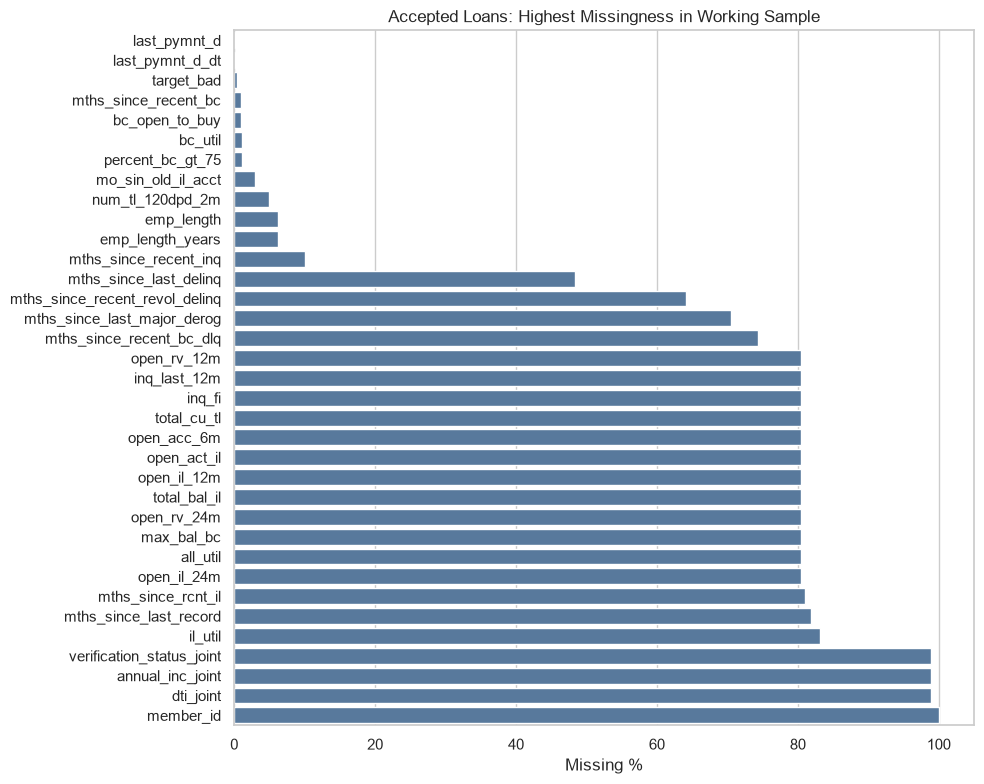

In [90]:
missingness = pd.DataFrame({
    "column": accepted.columns,
    "missing_count": accepted.isna().sum().values,
    "missing_pct": accepted.isna().mean().mul(100).round(2).values,
    "dtype": accepted.dtypes.astype(str).values,
    "non_null": accepted.notna().sum().values,
}).sort_values("missing_pct", ascending=False)

display_and_save_table(missingness, "accepted_working_sample_missingness")

plt.figure(figsize=(10, 8))
plot_df = missingness.head(35).sort_values("missing_pct")
sns.barplot(data=plot_df, x="missing_pct", y="column", color="#4C78A8")
plt.title("Accepted Loans: Highest Missingness in Working Sample")
plt.xlabel("Missing %")
plt.ylabel("")
save_current_plot("accepted_highest_missingness")
plt.show()


In [91]:
important_slices = [c for c in ["issue_year", "grade", "application_type", "loan_status"] if c in accepted]
important_missing_cols = [
    c for c in [
        "annual_inc", "dti", "fico_mean", "revol_util_clean", "emp_length_years",
        "mort_acc", "bc_util", "annual_inc_joint", "dti_joint",
    ]
    if c in accepted
]


def missingness_pct_by_slice(
    df: pd.DataFrame,
    slice_col: str,
    feature_cols: list[str],
    min_stable_n: int = CONFIG.min_group_n,
) -> pd.DataFrame:
    """Return readable slice-level null counts and percentages with explicit denominators."""
    grouped = df.groupby(slice_col, dropna=False)
    counts = grouped.size().reset_index(name="n_rows")
    missing_counts = grouped[feature_cols].apply(lambda x: x.isna().sum()).reset_index()
    missing_pct = grouped[feature_cols].apply(lambda x: x.isna().mean().mul(100).round(2)).reset_index()

    missing_counts = missing_counts.rename(columns={feature: f"{feature}_missing_count" for feature in feature_cols})
    missing_pct = missing_pct.rename(columns={feature: f"{feature}_missing_pct" for feature in feature_cols})

    out = counts.merge(missing_counts, on=slice_col, how="left").merge(missing_pct, on=slice_col, how="left")
    out["small_group_flag"] = np.where(out["n_rows"] < min_stable_n, "unstable_small_n", "ok")

    ordered_cols = [slice_col, "n_rows", "small_group_flag"]
    for feature in feature_cols:
        ordered_cols.extend([f"{feature}_missing_count", f"{feature}_missing_pct"])
    return out[ordered_cols]


for slice_col in important_slices:
    slice_missing = missingness_pct_by_slice(accepted, slice_col, important_missing_cols)
    display_and_save_table(slice_missing, f"missingness_by_{slice_col}")


,issue_year,n_rows,small_group_flag,annual_inc_missing_count,annual_inc_missing_pct,dti_missing_count,dti_missing_pct,fico_mean_missing_count,fico_mean_missing_pct,revol_util_clean_missing_count,revol_util_clean_missing_pct,emp_length_years_missing_count,emp_length_years_missing_pct,mort_acc_missing_count,mort_acc_missing_pct,bc_util_missing_count,bc_util_missing_pct,annual_inc_joint_missing_count,annual_inc_joint_missing_pct,dti_joint_missing_count,dti_joint_missing_pct
0,2015,163399,ok,0,0.0,0,0.00,0,0.0,78,0.05,9697,5.93,0,0.0,1646,1.01,163171,99.86,163171,99.86
1,2016,11844,ok,0,0.0,1,0.01,0,0.0,6,0.05,778,6.57,0,0.0,135,1.14,11679,98.61,11679,98.61
2,2017,8709,ok,0,0.0,13,0.15,0,0.0,6,0.07,631,7.25,0,0.0,133,1.53,7787,89.41,7787,89.41
3,2018,6197,ok,0,0.0,26,0.42,0,0.0,5,0.08,586,9.46,0,0.0,88,1.42,5323,85.90,5323,85.90


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/missingness_by_issue_year.csv


,grade,n_rows,small_group_flag,annual_inc_missing_count,annual_inc_missing_pct,dti_missing_count,dti_missing_pct,fico_mean_missing_count,fico_mean_missing_pct,revol_util_clean_missing_count,revol_util_clean_missing_pct,emp_length_years_missing_count,emp_length_years_missing_pct,mort_acc_missing_count,mort_acc_missing_pct,bc_util_missing_count,bc_util_missing_pct,annual_inc_joint_missing_count,annual_inc_joint_missing_pct,dti_joint_missing_count,dti_joint_missing_pct
0,A,35825,ok,0,0.0,3,0.01,0,0.0,6,0.02,2019,5.64,0,0.0,153,0.43,35549,99.23,35549,99.23
1,B,54569,ok,0,0.0,7,0.01,0,0.0,16,0.03,3261,5.98,0,0.0,435,0.80,54049,99.05,54049,99.05
2,C,53690,ok,0,0.0,12,0.02,0,0.0,31,0.06,3399,6.33,0,0.0,630,1.17,52996,98.71,52996,98.71
3,D,26777,ok,0,0.0,14,0.05,0,0.0,25,0.09,1923,7.18,0,0.0,422,1.58,26381,98.52,26381,98.52
4,E,13977,ok,0,0.0,3,0.02,0,0.0,13,0.09,811,5.80,0,0.0,247,1.77,13778,98.58,13778,98.58
5,F,4198,ok,0,0.0,1,0.02,0,0.0,2,0.05,216,5.15,0,0.0,78,1.86,4129,98.36,4129,98.36
6,G,1113,ok,0,0.0,0,0.00,0,0.0,2,0.18,63,5.66,0,0.0,37,3.32,1078,96.86,1078,96.86


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/missingness_by_grade.csv


,application_type,n_rows,small_group_flag,annual_inc_missing_count,annual_inc_missing_pct,dti_missing_count,dti_missing_pct,fico_mean_missing_count,fico_mean_missing_pct,revol_util_clean_missing_count,revol_util_clean_missing_pct,emp_length_years_missing_count,emp_length_years_missing_pct,mort_acc_missing_count,mort_acc_missing_pct,bc_util_missing_count,bc_util_missing_pct,annual_inc_joint_missing_count,annual_inc_joint_missing_pct,dti_joint_missing_count,dti_joint_missing_pct
0,Individual,187960,ok,0,0.0,0,0.00,0,0.0,93,0.05,11332,6.03,0,0.0,1954,1.04,187960,100.0,187960,100.0
1,Joint App,2189,ok,0,0.0,40,1.83,0,0.0,2,0.09,360,16.45,0,0.0,48,2.19,0,0.0,0,0.0


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/missingness_by_application_type.csv


,loan_status,n_rows,small_group_flag,annual_inc_missing_count,annual_inc_missing_pct,dti_missing_count,dti_missing_pct,fico_mean_missing_count,fico_mean_missing_pct,revol_util_clean_missing_count,revol_util_clean_missing_pct,emp_length_years_missing_count,emp_length_years_missing_pct,mort_acc_missing_count,mort_acc_missing_pct,bc_util_missing_count,bc_util_missing_pct,annual_inc_joint_missing_count,annual_inc_joint_missing_pct,dti_joint_missing_count,dti_joint_missing_pct
0,Charged Off,38709,ok,0,0.0,10,0.03,0,0.0,24,0.06,3005,7.76,0,0.0,424,1.10,38206,98.70,38206,98.70
1,Default,2,unstable_small_n,0,0.0,0,0.00,0,0.0,0,0.00,0,0.00,0,0.0,1,50.00,2,100.00,2,100.00
2,Fully Paid,148646,ok,0,0.0,28,0.02,0,0.0,70,0.05,8498,5.72,0,0.0,1544,1.04,147228,99.05,147228,99.05
3,In Grace Period,697,ok,0,0.0,0,0.00,0,0.0,0,0.00,32,4.59,0,0.0,8,1.15,618,88.67,618,88.67
4,Late (16-30 days),343,unstable_small_n,0,0.0,1,0.29,0,0.0,0,0.00,28,8.16,0,0.0,4,1.17,310,90.38,310,90.38
5,Late (31-120 days),1752,ok,0,0.0,1,0.06,0,0.0,1,0.06,129,7.36,0,0.0,21,1.20,1596,91.10,1596,91.10


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/missingness_by_loan_status.csv


## 7.1 Automated Missingness Mechanism Screening

**Description:** This section screens fields for missingness patterns that are consistent with MCAR-like behavior, MAR/structural behavior, or cases requiring domain review.

**Importance:** The missingness mechanism affects imputation and feature design. A single global median imputation is weak when missingness is systematic by application type, vintage, grade, or outcome.

**Process Made:** The notebook compares missingness across observed slices such as `application_type`, `loan_status`, `issue_year`, and `grade`, then summarizes whether variation suggests structural or MAR-like patterns.

**Expected Results:** A prioritization table that helps decide where simple imputation is sufficient and where missingness indicators, conditional treatment, or domain review are needed.

**Caveats:** MCAR, MAR, and MNAR cannot be proven fully from observed data alone. MNAR especially requires domain or collection-process evidence because it depends on unobserved values.


In [92]:
mechanism_candidate_cols = [
    c for c in [
        "annual_inc", "dti", "fico_mean", "revol_util_clean", "emp_length_years",
        "mort_acc", "bc_util", "annual_inc_joint", "dti_joint",
        "mths_since_last_record", "mths_since_last_delinq", "mths_since_recent_bc_dlq",
    ]
    if c in accepted
]

mechanism_slice_cols = [c for c in ["application_type", "loan_status", "issue_year", "grade"] if c in accepted]


def missing_pct_gap(df: pd.DataFrame, feature: str, slice_col: str, min_n: int = CONFIG.min_group_n) -> tuple[float, str]:
    grouped = (
        df.groupby(slice_col, dropna=False)[feature]
        .agg(group_rows="size", missing_pct=lambda x: x.isna().mean() * 100)
        .reset_index()
    )
    stable = grouped[grouped["group_rows"] >= min_n]
    if stable.empty or stable["missing_pct"].isna().all():
        return np.nan, "no_stable_groups"
    max_row = stable.loc[stable["missing_pct"].idxmax()]
    min_row = stable.loc[stable["missing_pct"].idxmin()]
    gap = round(float(max_row["missing_pct"] - min_row["missing_pct"]), 2)
    detail = f"{slice_col}: {max_row[slice_col]} {max_row['missing_pct']:.2f}% vs {min_row[slice_col]} {min_row['missing_pct']:.2f}%"
    return gap, detail


def target_missingness_gap(df: pd.DataFrame, feature: str) -> tuple[float, str]:
    if "target_bad" not in df:
        return np.nan, "target_bad unavailable"
    tmp = df[df["target_bad"].notna()].copy()
    if tmp.empty or tmp[feature].isna().sum() == 0:
        return np.nan, "no missing completed rows"
    missing = tmp[feature].isna()
    if missing.nunique() < 2:
        return np.nan, "missing indicator has one level"
    bad_when_missing = tmp.loc[missing, "target_bad"].mean()
    bad_when_observed = tmp.loc[~missing, "target_bad"].mean()
    gap = round(float((bad_when_missing - bad_when_observed) * 100), 2)
    detail = f"bad rate missing {bad_when_missing:.2%} vs observed {bad_when_observed:.2%}"
    return gap, detail


mechanism_rows = []
for feature in mechanism_candidate_cols:
    total_rows = len(accepted)
    missing_count = int(accepted[feature].isna().sum())
    missing_pct = round(missing_count / total_rows * 100, 2) if total_rows else np.nan

    slice_gaps = {}
    slice_details = {}
    for slice_col in mechanism_slice_cols:
        gap, detail = missing_pct_gap(accepted, feature, slice_col)
        slice_gaps[slice_col] = gap
        slice_details[slice_col] = detail

    target_gap, target_detail = target_missingness_gap(accepted, feature)
    valid_gaps = [v for v in slice_gaps.values() if not pd.isna(v)]
    max_slice_gap = round(max(valid_gaps), 2) if valid_gaps else np.nan

    structural_reason = ""
    if feature.endswith("_joint") and "application_type" in slice_gaps and slice_gaps["application_type"] >= 80:
        mechanism_screen = "structural_missingness"
        structural_reason = "Joint-applicant field; missingness is expected for Individual applications."
        recommended_action = "Handle conditionally by application_type or exclude from first-pass model."
    elif (not pd.isna(max_slice_gap) and max_slice_gap >= 5) or (not pd.isna(target_gap) and abs(target_gap) >= 2):
        mechanism_screen = "potential_MAR_observed_pattern"
        recommended_action = "Preserve missingness indicator later and validate imputation/model impact."
    elif missing_count == 0:
        mechanism_screen = "no_missingness_observed"
        recommended_action = "No missingness action needed in this working sample."
    else:
        mechanism_screen = "consistent_with_MCAR_screen"
        recommended_action = "Simple imputation may be acceptable; validate during modeling."

    mechanism_rows.append({
        "feature": feature,
        "missing_count": missing_count,
        "missing_pct": missing_pct,
        "max_observed_slice_gap_pct_points": max_slice_gap,
        "application_type_gap_detail": slice_details.get("application_type", ""),
        "loan_status_gap_detail": slice_details.get("loan_status", ""),
        "issue_year_gap_detail": slice_details.get("issue_year", ""),
        "grade_gap_detail": slice_details.get("grade", ""),
        "target_bad_rate_gap_pct_points": target_gap,
        "target_gap_detail": target_detail,
        "mechanism_screen": mechanism_screen,
        "structural_reason": structural_reason,
        "mnar_note": "MNAR not identifiable from observed data alone.",
        "recommended_action": recommended_action,
    })

missingness_mechanism_screening = pd.DataFrame(mechanism_rows).sort_values(
    ["mechanism_screen", "missing_pct"], ascending=[True, False]
)
display_and_save_table(missingness_mechanism_screening, "accepted_missingness_mechanism_screening")


,feature,missing_count,missing_pct,max_observed_slice_gap_pct_points,application_type_gap_detail,loan_status_gap_detail,issue_year_gap_detail,grade_gap_detail,target_bad_rate_gap_pct_points,target_gap_detail,mechanism_screen,structural_reason,mnar_note,recommended_action
6,bc_util,2002,1.05,2.90,application_type: Joint App 2.19% vs Individua...,loan_status: Late (31-120 days) 1.20% vs Fully...,issue_year: 2017.0 1.53% vs 2015.0 1.01%,grade: G 3.32% vs A 0.43%,1.04,bad rate missing 22.57% vs observed 21.53%,consistent_with_MCAR_screen,,MNAR not identifiable from observed data alone.,Simple imputation may be acceptable; validate ...
0,annual_inc,0,0.00,0.00,application_type: Individual 0.00% vs Individu...,loan_status: Charged Off 0.00% vs Charged Off ...,issue_year: 2015.0 0.00% vs 2015.0 0.00%,grade: A 0.00% vs A 0.00%,NaN,no missing completed rows,no_missingness_observed,,MNAR not identifiable from observed data alone.,No missingness action needed in this working s...
2,fico_mean,0,0.00,0.00,application_type: Individual 0.00% vs Individu...,loan_status: Charged Off 0.00% vs Charged Off ...,issue_year: 2015.0 0.00% vs 2015.0 0.00%,grade: A 0.00% vs A 0.00%,NaN,no missing completed rows,no_missingness_observed,,MNAR not identifiable from observed data alone.,No missingness action needed in this working s...
5,mort_acc,0,0.00,0.00,application_type: Individual 0.00% vs Individu...,loan_status: Charged Off 0.00% vs Charged Off ...,issue_year: 2015.0 0.00% vs 2015.0 0.00%,grade: A 0.00% vs A 0.00%,NaN,no missing completed rows,no_missingness_observed,,MNAR not identifiable from observed data alone.,No missingness action needed in this working s...
9,mths_since_last_record,155550,81.80,12.37,application_type: Joint App 83.14% vs Individu...,loan_status: In Grace Period 85.22% vs Charged...,issue_year: 2018.0 84.40% vs 2016.0 80.01%,grade: A 90.09% vs G 77.72%,-3.54,bad rate missing 20.89% vs observed 24.43%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
11,mths_since_recent_bc_dlq,141245,74.28,8.48,application_type: Joint App 79.40% vs Individu...,loan_status: In Grace Period 74.75% vs Charged...,issue_year: 2018.0 79.02% vs 2016.0 73.74%,grade: A 80.00% vs G 71.52%,-1.44,bad rate missing 21.17% vs observed 22.61%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
10,mths_since_last_delinq,92116,48.44,14.34,application_type: Joint App 50.21% vs Individu...,loan_status: Fully Paid 48.97% vs Late (31-120...,issue_year: 2018.0 55.17% vs 2016.0 47.30%,grade: A 57.47% vs G 43.13%,-1.62,bad rate missing 20.71% vs observed 22.32%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
4,emp_length_years,11692,6.15,10.42,application_type: Joint App 16.45% vs Individu...,loan_status: Charged Off 7.76% vs In Grace Per...,issue_year: 2018.0 9.46% vs 2015.0 5.93%,grade: D 7.18% vs F 5.15%,5.95,bad rate missing 27.12% vs observed 21.17%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
3,revol_util_clean,95,0.05,0.16,application_type: Joint App 0.09% vs Individua...,loan_status: Charged Off 0.06% vs In Grace Per...,issue_year: 2018.0 0.08% vs 2015.0 0.05%,grade: G 0.18% vs A 0.02%,4.78,bad rate missing 26.32% vs observed 21.54%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
1,dti,40,0.02,1.83,application_type: Joint App 1.83% vs Individua...,loan_status: Late (31-120 days) 0.06% vs In Gr...,issue_year: 2018.0 0.42% vs 2015.0 0.00%,grade: D 0.05% vs G 0.00%,8.46,bad rate missing 30.00% vs observed 21.54%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_missingness_mechanism_screening.csv


,feature,missing_count,missing_pct,max_observed_slice_gap_pct_points,application_type_gap_detail,loan_status_gap_detail,issue_year_gap_detail,grade_gap_detail,target_bad_rate_gap_pct_points,target_gap_detail,mechanism_screen,structural_reason,mnar_note,recommended_action
6,bc_util,2002,1.05,2.90,application_type: Joint App 2.19% vs Individua...,loan_status: Late (31-120 days) 1.20% vs Fully...,issue_year: 2017.0 1.53% vs 2015.0 1.01%,grade: G 3.32% vs A 0.43%,1.04,bad rate missing 22.57% vs observed 21.53%,consistent_with_MCAR_screen,,MNAR not identifiable from observed data alone.,Simple imputation may be acceptable; validate ...
0,annual_inc,0,0.00,0.00,application_type: Individual 0.00% vs Individu...,loan_status: Charged Off 0.00% vs Charged Off ...,issue_year: 2015.0 0.00% vs 2015.0 0.00%,grade: A 0.00% vs A 0.00%,NaN,no missing completed rows,no_missingness_observed,,MNAR not identifiable from observed data alone.,No missingness action needed in this working s...
2,fico_mean,0,0.00,0.00,application_type: Individual 0.00% vs Individu...,loan_status: Charged Off 0.00% vs Charged Off ...,issue_year: 2015.0 0.00% vs 2015.0 0.00%,grade: A 0.00% vs A 0.00%,NaN,no missing completed rows,no_missingness_observed,,MNAR not identifiable from observed data alone.,No missingness action needed in this working s...
5,mort_acc,0,0.00,0.00,application_type: Individual 0.00% vs Individu...,loan_status: Charged Off 0.00% vs Charged Off ...,issue_year: 2015.0 0.00% vs 2015.0 0.00%,grade: A 0.00% vs A 0.00%,NaN,no missing completed rows,no_missingness_observed,,MNAR not identifiable from observed data alone.,No missingness action needed in this working s...
9,mths_since_last_record,155550,81.80,12.37,application_type: Joint App 83.14% vs Individu...,loan_status: In Grace Period 85.22% vs Charged...,issue_year: 2018.0 84.40% vs 2016.0 80.01%,grade: A 90.09% vs G 77.72%,-3.54,bad rate missing 20.89% vs observed 24.43%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
11,mths_since_recent_bc_dlq,141245,74.28,8.48,application_type: Joint App 79.40% vs Individu...,loan_status: In Grace Period 74.75% vs Charged...,issue_year: 2018.0 79.02% vs 2016.0 73.74%,grade: A 80.00% vs G 71.52%,-1.44,bad rate missing 21.17% vs observed 22.61%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
10,mths_since_last_delinq,92116,48.44,14.34,application_type: Joint App 50.21% vs Individu...,loan_status: Fully Paid 48.97% vs Late (31-120...,issue_year: 2018.0 55.17% vs 2016.0 47.30%,grade: A 57.47% vs G 43.13%,-1.62,bad rate missing 20.71% vs observed 22.32%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
4,emp_length_years,11692,6.15,10.42,application_type: Joint App 16.45% vs Individu...,loan_status: Charged Off 7.76% vs In Grace Per...,issue_year: 2018.0 9.46% vs 2015.0 5.93%,grade: D 7.18% vs F 5.15%,5.95,bad rate missing 27.12% vs observed 21.17%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
3,revol_util_clean,95,0.05,0.16,application_type: Joint App 0.09% vs Individua...,loan_status: Charged Off 0.06% vs In Grace Per...,issue_year: 2018.0 0.08% vs 2015.0 0.05%,grade: G 0.18% vs A 0.02%,4.78,bad rate missing 26.32% vs observed 21.54%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...
1,dti,40,0.02,1.83,application_type: Joint App 1.83% vs Individua...,loan_status: Late (31-120 days) 0.06% vs In Gr...,issue_year: 2018.0 0.42% vs 2015.0 0.00%,grade: D 0.05% vs G 0.00%,8.46,bad rate missing 30.00% vs observed 21.54%,potential_MAR_observed_pattern,,MNAR not identifiable from observed data alone.,Preserve missingness indicator later and valid...


## 8. Univariate Portfolio EDA

**Description:** This section profiles the one-variable distributions of accepted-loan portfolio attributes such as loan amount, interest rate, term, grade, purpose, home ownership, income, DTI, FICO, utilization, and credit history.

**Importance:** Univariate EDA establishes whether the portfolio looks economically plausible before modeling. It helps identify skew, outliers, sparse categories, dominant product segments, and variables requiring transformation or binning.

**Process Made:** The notebook exports numeric summaries, categorical summaries, and distribution plots for selected application-time and credit-bureau variables.

**Expected Results:** Tables and plots showing central tendency, spread, tails, top categories, and portfolio mix across core credit-risk drivers.

**Caveats:** Univariate analysis does not explain default by itself. A variable can look reasonable marginally but still interact strongly with term, grade, vintage, or pricing.


In [93]:
NUMERIC_EDA_COLS = [
    "loan_amnt", "int_rate_clean", "installment", "annual_inc", "dti", "fico_mean",
    "emp_length_years", "credit_history_years", "open_acc", "revol_bal", "revol_util_clean",
    "total_acc", "mort_acc", "bc_util", "total_rev_hi_lim", "tot_cur_bal",
]
NUMERIC_EDA_COLS = [c for c in NUMERIC_EDA_COLS if c in accepted]

numeric_summary = accepted[NUMERIC_EDA_COLS].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numeric_summary["missing_pct"] = accepted[NUMERIC_EDA_COLS].isna().mean().mul(100).round(2)
display_and_save_table(numeric_summary.reset_index(names="column"), "accepted_numeric_summary")


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
0,loan_amnt,190149.0,14661.940242,8682.459217,1000.0,1700.0,3500.0,8000.0,12500.0,20000.0,33000.0,35000.0,40000.0,0.00
1,int_rate_clean,190149.0,12.506112,4.50937,5.31,5.32,6.24,9.17,12.29,15.31,20.0,25.81,30.99,0.00
2,installment,190149.0,439.149357,257.29465,30.12,56.69,115.31,251.4,377.04,582.75,950.632,1196.05,1607.8,0.00
3,annual_inc,190149.0,76870.671609,82743.195452,0.0,18000.0,28000.0,45550.0,65000.0,90500.0,160000.0,260000.0,9573072.0,0.00
4,dti,190109.0,18.960541,10.405256,0.0,2.12,5.4,12.28,18.27,25.08,34.24,38.68,999.0,0.02
5,fico_mean,190149.0,696.455012,31.135703,662.0,662.0,662.0,672.0,687.0,712.0,762.0,802.0,847.5,0.00
6,emp_length_years,178457.0,5.972565,3.715834,0.0,0.0,0.0,2.0,6.0,10.0,10.0,10.0,10.0,6.15
7,credit_history_years,190149.0,16.585407,7.628239,3.077344,3.838467,6.42026,11.411362,15.080082,20.418891,31.249829,40.418891,65.913758,0.00
8,open_acc,190149.0,11.862071,5.664929,1.0,3.0,5.0,8.0,11.0,15.0,23.0,30.0,81.0,0.00
9,revol_bal,190149.0,16896.4565,24177.266841,0.0,279.48,1843.4,6053.0,11274.0,20224.0,45873.0,101572.8,2904836.0,0.00


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_numeric_summary.csv


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
0,loan_amnt,190149.0,14661.940242,8682.459217,1000.0,1700.0,3500.0,8000.0,12500.0,20000.0,33000.0,35000.0,40000.0,0.00
1,int_rate_clean,190149.0,12.506112,4.50937,5.31,5.32,6.24,9.17,12.29,15.31,20.0,25.81,30.99,0.00
2,installment,190149.0,439.149357,257.29465,30.12,56.69,115.31,251.4,377.04,582.75,950.632,1196.05,1607.8,0.00
3,annual_inc,190149.0,76870.671609,82743.195452,0.0,18000.0,28000.0,45550.0,65000.0,90500.0,160000.0,260000.0,9573072.0,0.00
4,dti,190109.0,18.960541,10.405256,0.0,2.12,5.4,12.28,18.27,25.08,34.24,38.68,999.0,0.02
5,fico_mean,190149.0,696.455012,31.135703,662.0,662.0,662.0,672.0,687.0,712.0,762.0,802.0,847.5,0.00
6,emp_length_years,178457.0,5.972565,3.715834,0.0,0.0,0.0,2.0,6.0,10.0,10.0,10.0,10.0,6.15
7,credit_history_years,190149.0,16.585407,7.628239,3.077344,3.838467,6.42026,11.411362,15.080082,20.418891,31.249829,40.418891,65.913758,0.00
8,open_acc,190149.0,11.862071,5.664929,1.0,3.0,5.0,8.0,11.0,15.0,23.0,30.0,81.0,0.00
9,revol_bal,190149.0,16896.4565,24177.266841,0.0,279.48,1843.4,6053.0,11274.0,20224.0,45873.0,101572.8,2904836.0,0.00


In [94]:
CATEGORICAL_EDA_COLS = [
    "term", "grade", "sub_grade", "home_ownership", "verification_status", "purpose",
    "addr_state", "application_type", "initial_list_status", "disbursement_method",
]
CATEGORICAL_EDA_COLS = [c for c in CATEGORICAL_EDA_COLS if c in accepted]

for col in CATEGORICAL_EDA_COLS:
    print(f"\n{col}")
    display_and_save_table(categorical_summary(accepted, col, top_n=25).reset_index(names=col), f"categorical_summary_{col}")



term


,term,count,pct
0,36 months,143066,75.24
1,60 months,47083,24.76


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/categorical_summary_term.csv

grade


,grade,count,pct
0,B,54569,28.7
1,C,53690,28.24
2,A,35825,18.84
3,D,26777,14.08
4,E,13977,7.35
5,F,4198,2.21
6,G,1113,0.59


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/categorical_summary_grade.csv

sub_grade


...

Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/categorical_summary_application_type.csv

initial_list_status


,initial_list_status,count,pct
0,w,125959,66.24
1,f,64190,33.76


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/categorical_summary_initial_list_status.csv

disbursement_method


,disbursement_method,count,pct
0,Cash,189688,99.76
1,DirectPay,461,0.24


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/categorical_summary_disbursement_method.csv


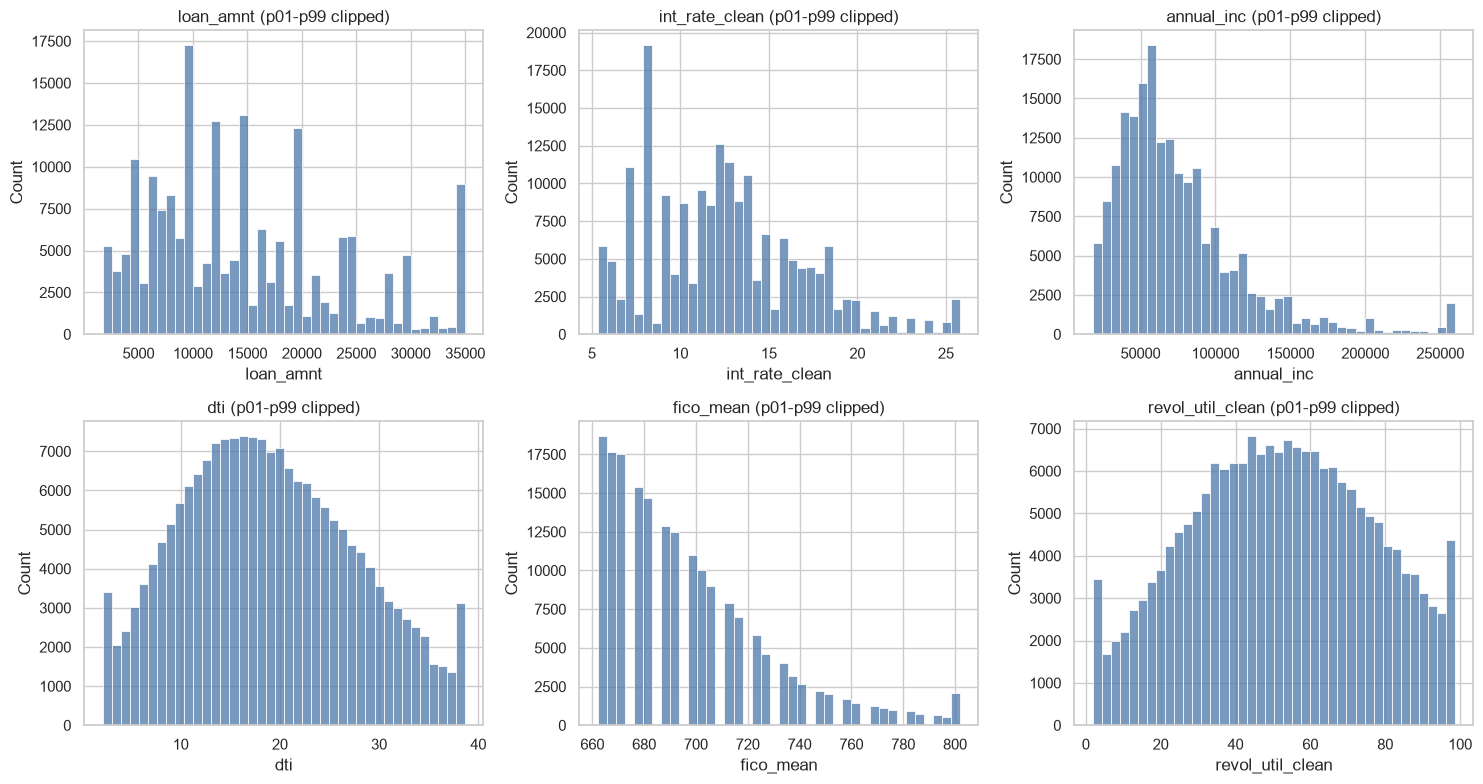

In [95]:
plot_numeric = [c for c in ["loan_amnt", "int_rate_clean", "annual_inc", "dti", "fico_mean", "revol_util_clean"] if c in accepted]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, plot_numeric):
    s = accepted[col].dropna()
    if s.empty:
        ax.set_visible(False)
        continue
    lo, hi = s.quantile([0.01, 0.99])
    sns.histplot(s.clip(lo, hi), bins=40, ax=ax, color="#4C78A8")
    ax.set_title(f"{col} (p01-p99 clipped)")
for ax in axes[len(plot_numeric):]:
    ax.set_visible(False)
save_current_plot("accepted_numeric_distributions")
plt.show()


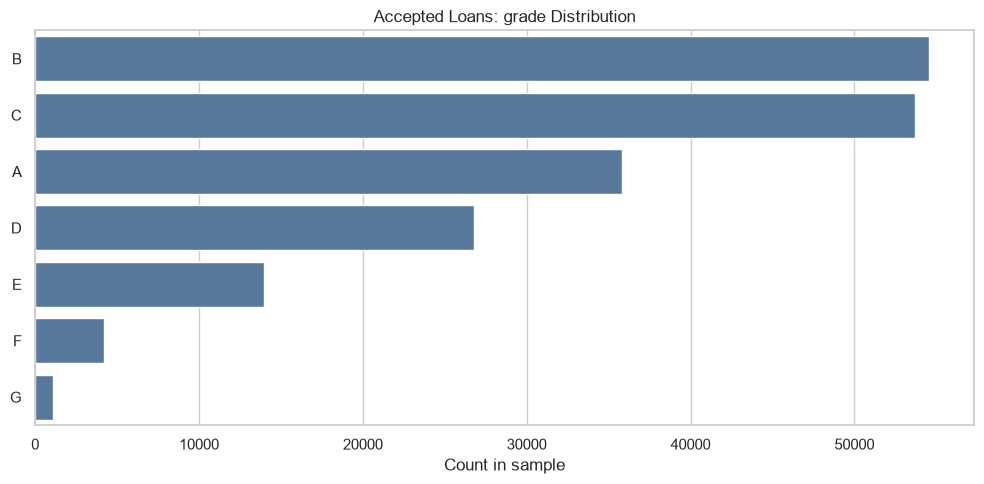

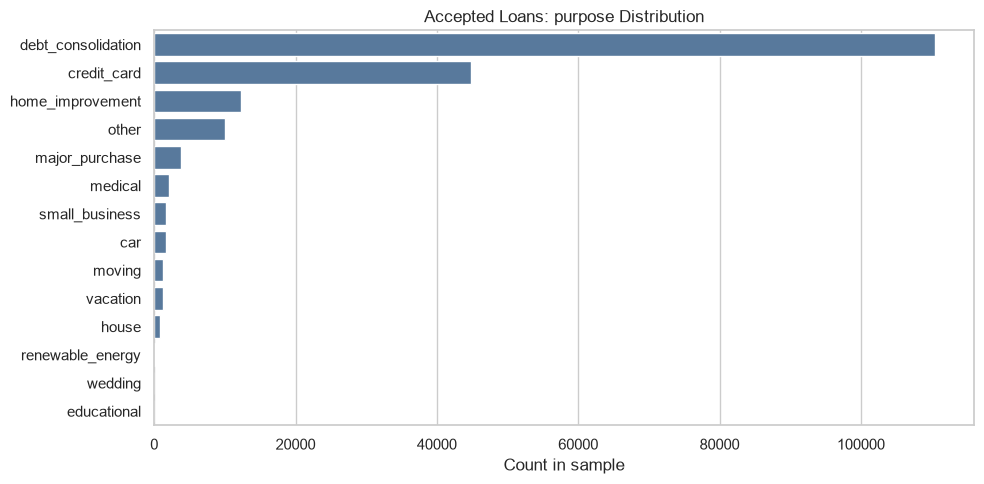

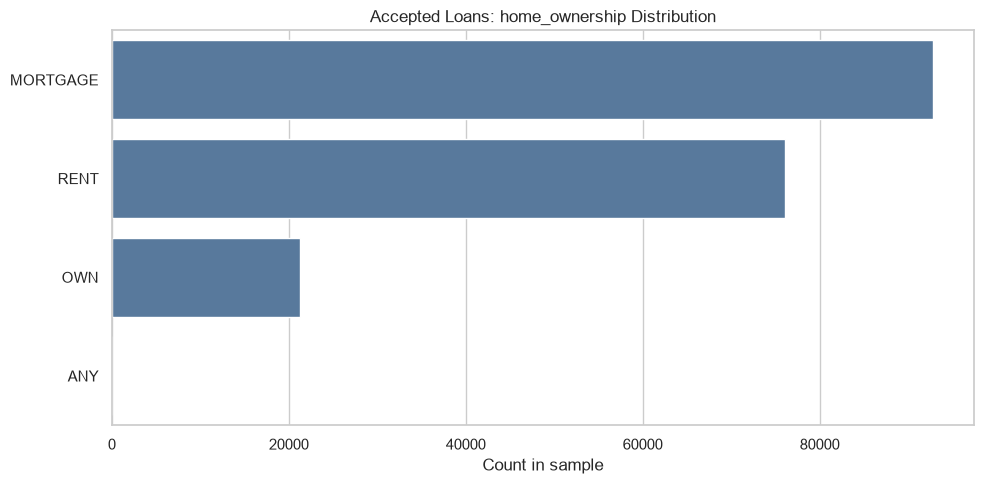

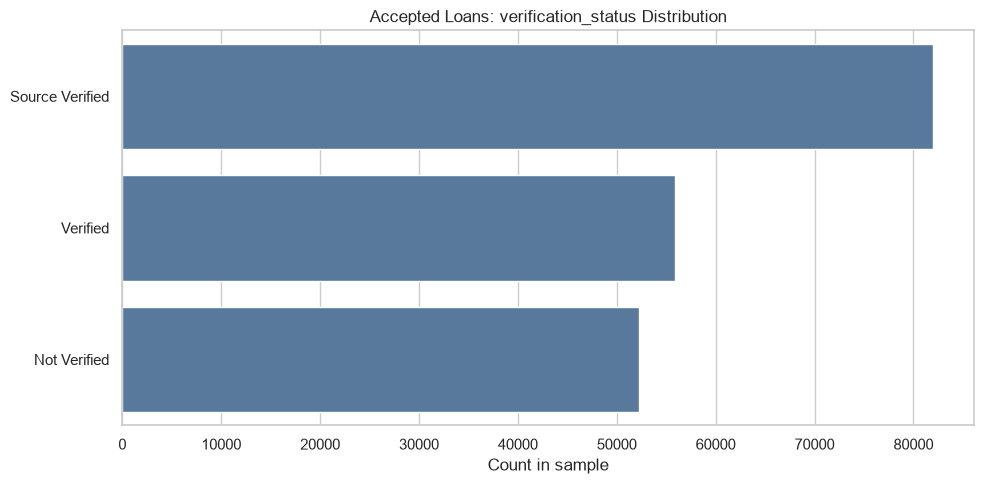

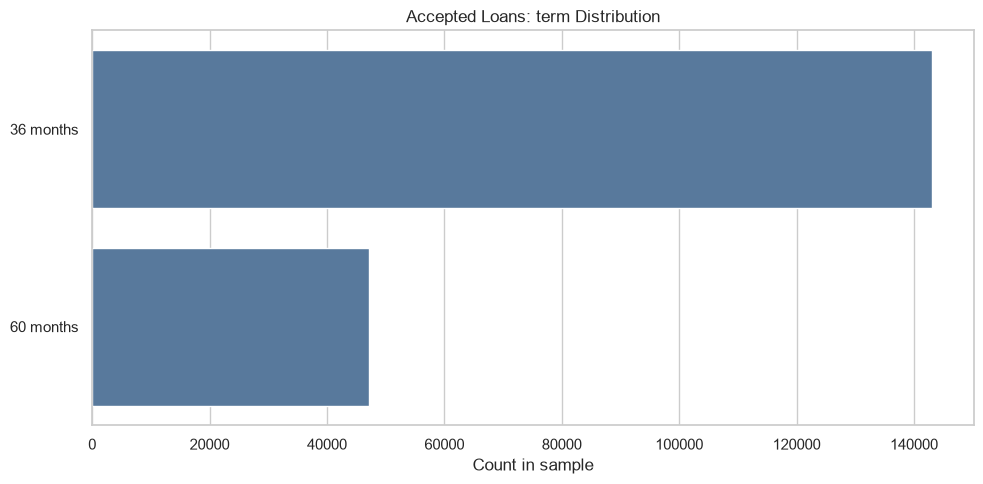

In [96]:
for col in ["grade", "purpose", "home_ownership", "verification_status", "term"]:
    if col not in accepted:
        continue
    plt.figure(figsize=(10, 5))
    order = accepted[col].value_counts().head(20).index
    sns.countplot(data=accepted, y=col, order=order, color="#4C78A8")
    plt.title(f"Accepted Loans: {col} Distribution")
    plt.xlabel("Count in sample")
    plt.ylabel("")
    save_current_plot(f"accepted_{col}_distribution")
    plt.show()


## 9. Temporal and Vintage EDA

**Description:** This section analyzes origination patterns and observed outcomes over issue time.

**Importance:** Credit-risk data is not IID over time. Borrower mix, LendingClub policy, grade composition, pricing, macro conditions, and credit performance changed from 2007 to 2018, so validation should be chronological and vintage-aware.

**Process Made:** The notebook summarizes portfolio volume, grade mix, loan amount, interest rate, and observed bad rates by issue year/month or vintage-related fields, then exports temporal plots and tables.

**Expected Results:** Evidence of time drift in portfolio composition, pricing, risk grades, and bad-rate patterns. These outputs support chronological train/validation/test split recommendations.

**Caveats:** Recent vintages may be censored because many loans have not fully matured. Observed bad rates by year should be interpreted alongside loan maturity and unresolved-status removal.


,issue_year,sample_loans,avg_loan_amnt,avg_int_rate,avg_fico,avg_dti
0,2015,163399,14671.49,12.35,695.74,18.94
1,2016,11844,14462.57,12.79,697.22,19.01
2,2017,8709,14243.70,14.42,699.79,19.29
3,2018,6197,15379.06,13.46,709.05,18.83


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_yearly_portfolio_summary.csv


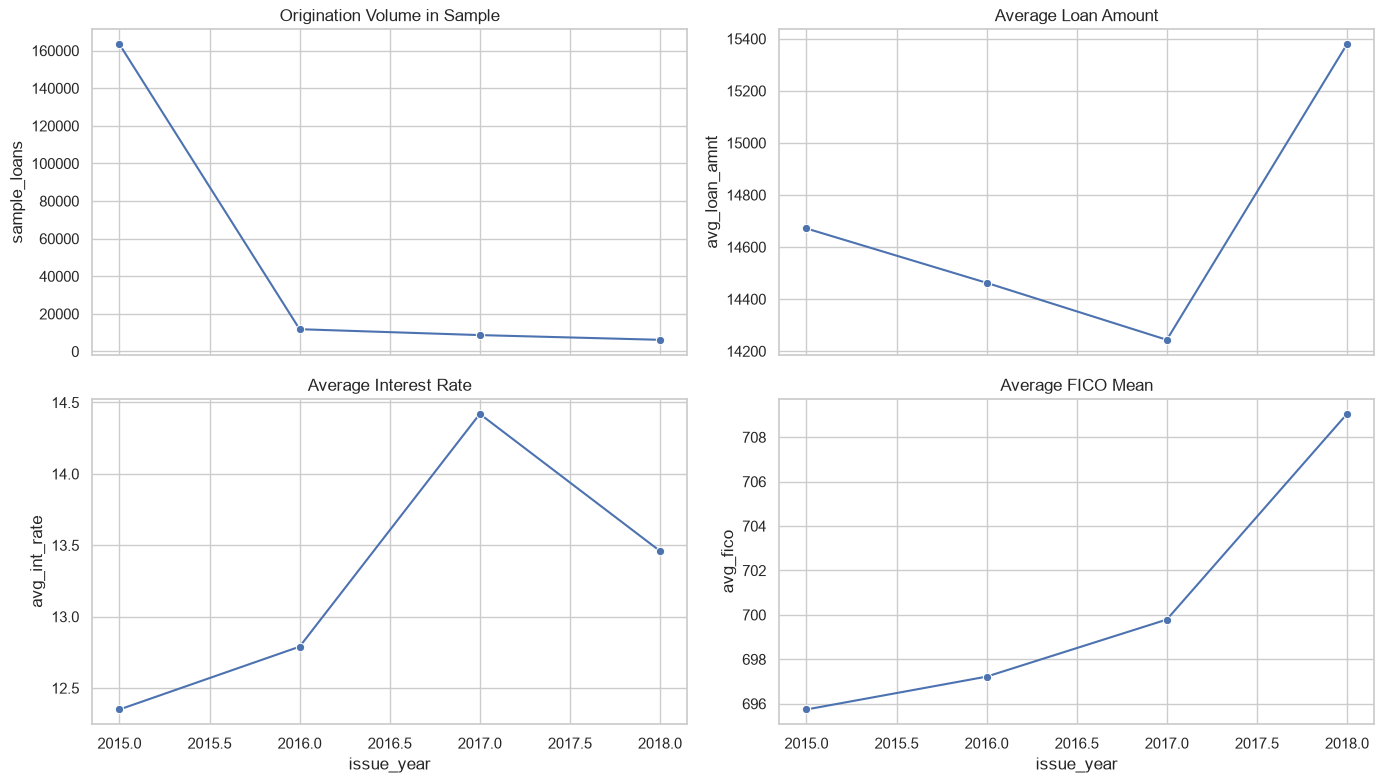

In [97]:
if "issue_year" in accepted:
    yearly = (
        accepted.groupby("issue_year", dropna=True)
        .agg(
            sample_loans=("id", "count") if "id" in accepted else ("loan_amnt", "count"),
            avg_loan_amnt=("loan_amnt", "mean"),
            avg_int_rate=("int_rate_clean", "mean"),
            avg_fico=("fico_mean", "mean"),
            avg_dti=("dti", "mean"),
        )
        .reset_index()
    )
    yearly[["avg_loan_amnt", "avg_int_rate", "avg_fico", "avg_dti"]] = yearly[["avg_loan_amnt", "avg_int_rate", "avg_fico", "avg_dti"]].round(2)
    display_and_save_table(yearly, "accepted_yearly_portfolio_summary")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    sns.lineplot(data=yearly, x="issue_year", y="sample_loans", marker="o", ax=axes[0, 0])
    axes[0, 0].set_title("Origination Volume in Sample")
    sns.lineplot(data=yearly, x="issue_year", y="avg_loan_amnt", marker="o", ax=axes[0, 1])
    axes[0, 1].set_title("Average Loan Amount")
    sns.lineplot(data=yearly, x="issue_year", y="avg_int_rate", marker="o", ax=axes[1, 0])
    axes[1, 0].set_title("Average Interest Rate")
    sns.lineplot(data=yearly, x="issue_year", y="avg_fico", marker="o", ax=axes[1, 1])
    axes[1, 1].set_title("Average FICO Mean")
    save_current_plot("accepted_temporal_portfolio_summary")
    plt.show()


,issue_year,grade,n,pct_within_year
0,2015,A,31012,18.979308
1,2015,B,47127,28.841670
2,2015,C,45664,27.946315
3,2015,D,22842,13.979278
4,2015,E,12339,7.551454
5,2015,F,3612,2.210540
6,2015,G,803,0.491435
7,2016,A,2312,19.520432
8,2016,B,3506,29.601486
9,2016,C,3284,27.727119


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_grade_mix_by_year.csv


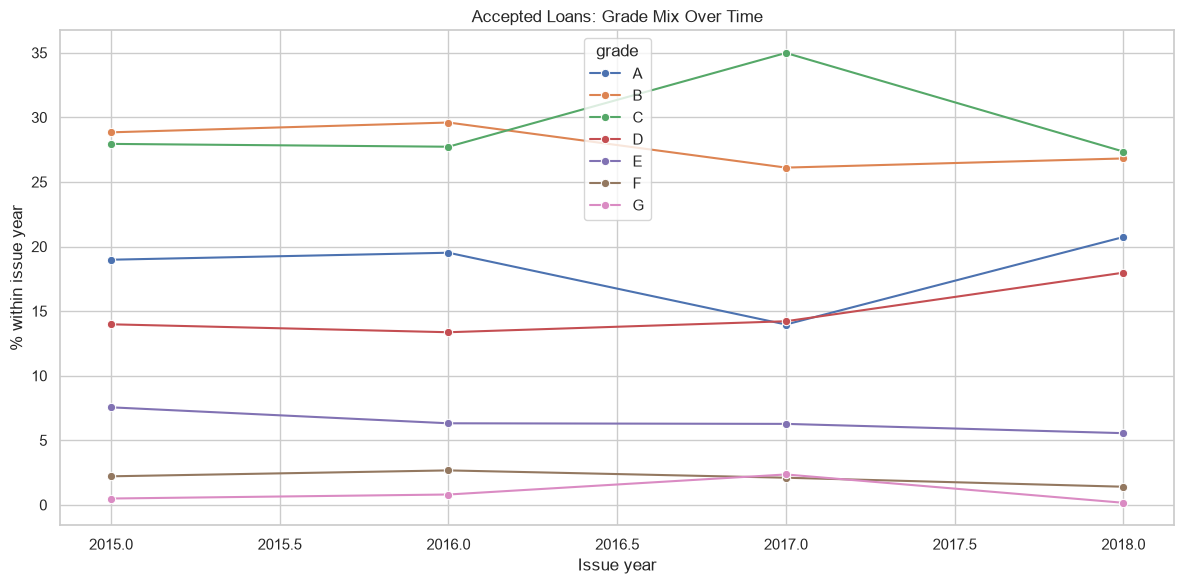

In [98]:
if {"issue_year", "grade"}.issubset(accepted.columns):
    grade_time = (
        accepted.groupby(["issue_year", "grade"], observed=True)
        .size()
        .reset_index(name="n")
    )
    grade_time["pct_within_year"] = grade_time.groupby("issue_year")["n"].transform(lambda x: x / x.sum() * 100)
    display_and_save_table(grade_time, "accepted_grade_mix_by_year")

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grade_time, x="issue_year", y="pct_within_year", hue="grade", marker="o")
    plt.title("Accepted Loans: Grade Mix Over Time")
    plt.ylabel("% within issue year")
    plt.xlabel("Issue year")
    save_current_plot("accepted_grade_mix_over_time")
    plt.show()


## 10. Outcome EDA and Observed Bad Rates

**Description:** This section studies observed repayment outcomes and bad rates across borrower, loan, pricing, and credit-risk groups.

**Importance:** Bad-rate EDA checks whether expected credit-risk relationships appear in the data: riskier grades, longer terms, higher DTI, lower FICO, and higher utilization should generally show higher observed bad rates.

**Process Made:** The notebook restricts bad-rate calculations to records with defined target outcomes, groups by categorical variables and binned numeric variables, applies minimum group-size thresholds, and exports bad-rate tables and plots.

**Expected Results:** Stable bad-rate rankings by grade, sub-grade, term, FICO band, DTI band, interest-rate band, income band, purpose, verification status, home ownership, and state where sample size is sufficient.

**Caveats:** Observed bad rates are descriptive, not causal. They can reflect underwriting selection, pricing, vintage mix, and macro conditions. Groups below the minimum denominator should not drive modeling or policy conclusions.


In [99]:
if len(completed):
    completed_summary = pd.DataFrame([
        {
            "completed_rows": len(completed),
            "good_rows": int((completed["target_bad"] == 0).sum()),
            "bad_rows": int((completed["target_bad"] == 1).sum()),
            "observed_bad_rate": round(completed["target_bad"].mean(), 4),
            "share_of_working_sample_completed": round(len(completed) / len(accepted), 4),
        }
    ])
    display_and_save_table(completed_summary, "accepted_completed_target_summary")


,completed_rows,good_rows,bad_rows,observed_bad_rate,share_of_working_sample_completed
0,189452,148646,40806,0.2154,0.9963


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_completed_target_summary.csv


,grade,n,bad_rate,bad_count
6,G,1100,0.5682,625
5,F,4168,0.5170,2155
4,E,13888,0.4373,6073
3,D,26618,0.3408,9071
2,C,53453,0.2444,13062
1,B,54446,0.1402,7634
0,A,35779,0.0611,2186


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_grade.csv


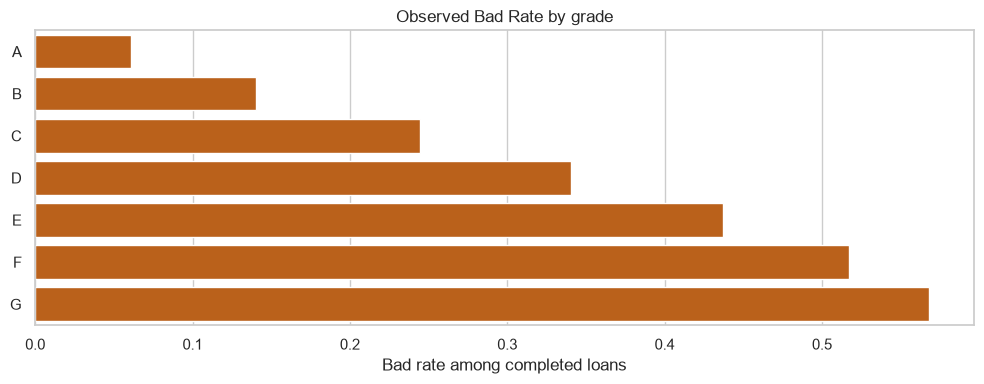

,sub_grade,n,bad_rate,bad_count
28,F4,598,0.5652,338
27,F3,732,0.5273,386
26,F2,1002,0.5160,517
24,E5,1915,0.4825,924
25,F1,1348,0.4763,642
23,E4,2290,0.4590,1051
22,E3,2918,0.4435,1294
21,E2,3209,0.4279,1373
20,E1,3556,0.4024,1431
19,D5,4182,0.3824,1599


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_sub_grade.csv


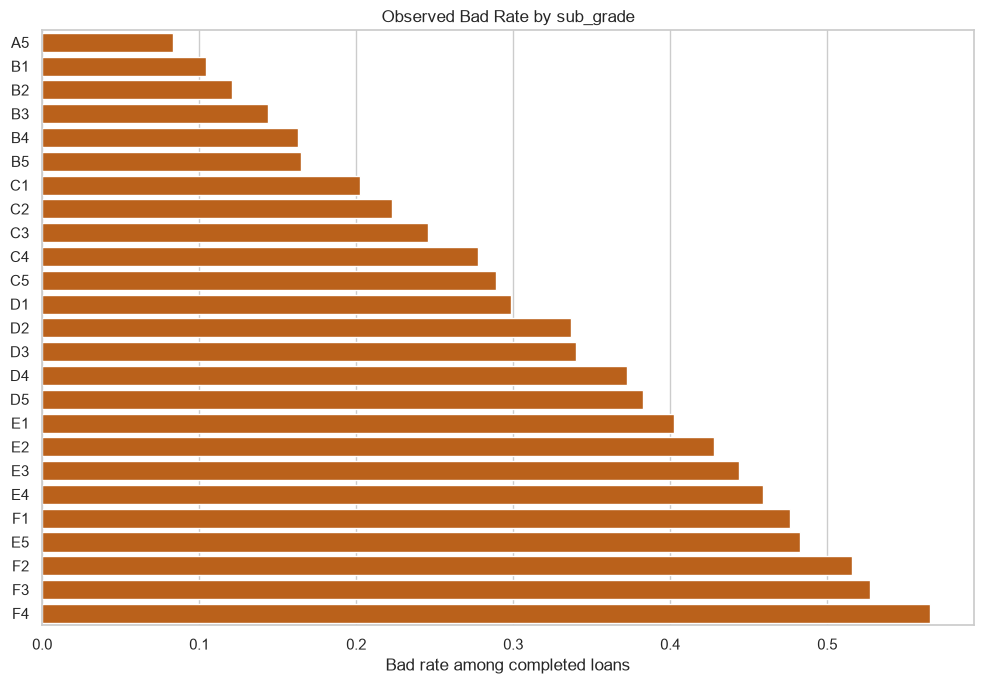

,term,n,bad_rate,bad_count
1,60 months,46649,0.3792,17690
0,36 months,142803,0.1619,23116


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_term.csv


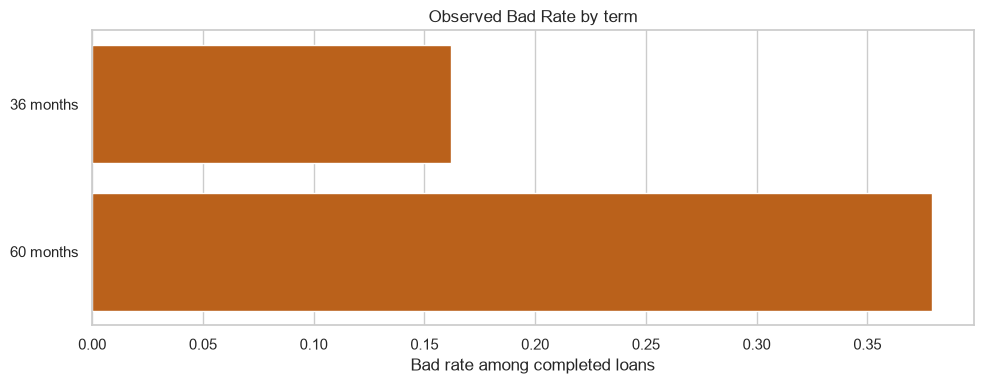

,purpose,n,bad_rate,bad_count
11,small_business,1696,0.3196,542
8,moving,1258,0.2790,351
5,house,755,0.2570,194
7,medical,2059,0.2351,484
2,debt_consolidation,110032,0.2297,25276
9,other,9993,0.2258,2256
6,major_purchase,3727,0.2165,807
12,vacation,1194,0.1926,230
4,home_improvement,12315,0.1910,2352
1,credit_card,44669,0.1789,7993


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_purpose.csv


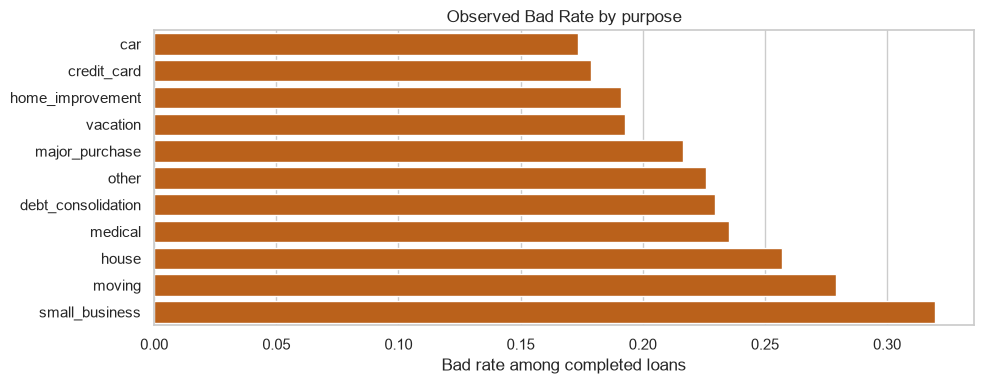

,home_ownership,n,bad_rate,bad_count
3,RENT,75783,0.2489,18860
2,OWN,21207,0.2184,4631
1,MORTGAGE,92461,0.1873,17315


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_home_ownership.csv


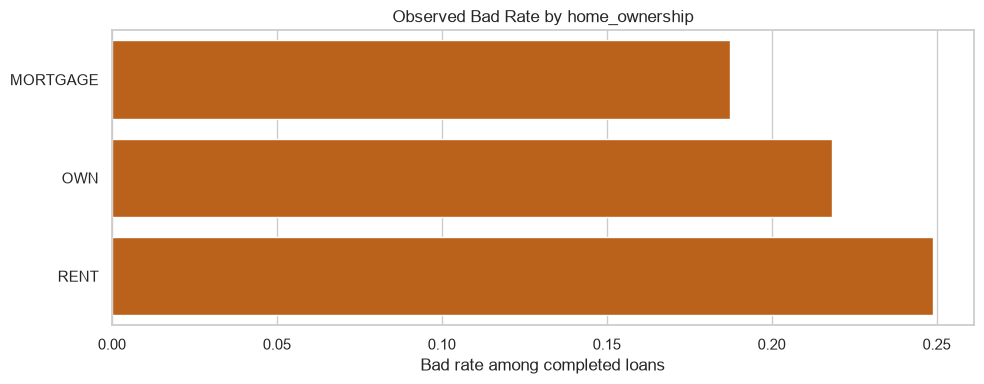

,verification_status,n,bad_rate,bad_count
2,Verified,55670,0.2651,14756
1,Source Verified,81713,0.2181,17821
0,Not Verified,52069,0.1580,8229


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_verification_status.csv


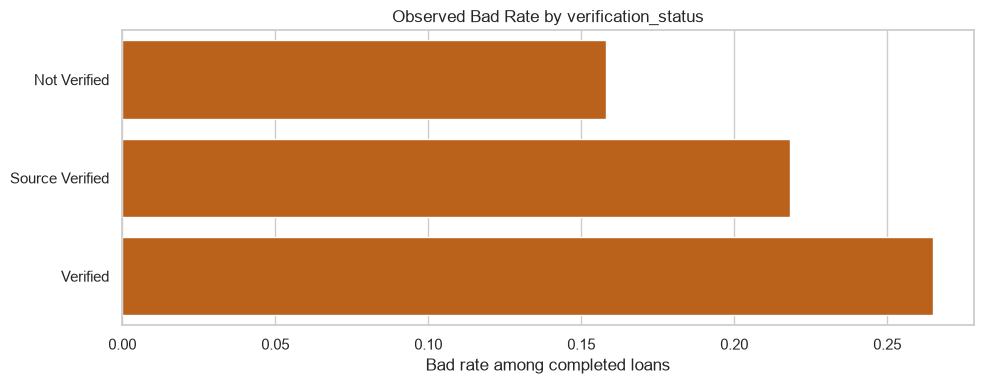

,application_type,n,bad_rate,bad_count
1,Joint App,2110,0.3280,692
0,Individual,187342,0.2141,40114


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_application_type.csv


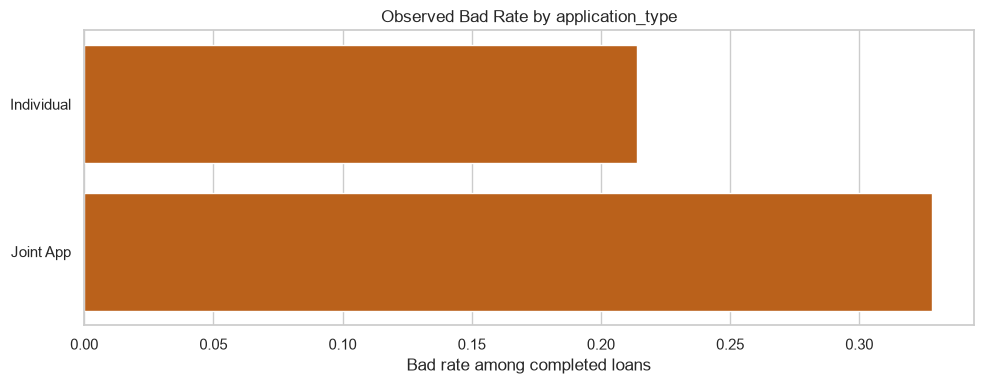

,addr_state,n,bad_rate,bad_count
2,AR,1449,0.2836,411
28,NE,678,0.2802,190
35,OK,1709,0.2686,459
17,LA,2241,0.2677,600
24,MS,1158,0.2668,309
1,AL,2334,0.2588,604
33,NY,15256,0.2383,3635
23,MO,2968,0.2352,698
37,PA,6434,0.2344,1508
32,NV,2831,0.2314,655


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_addr_state.csv


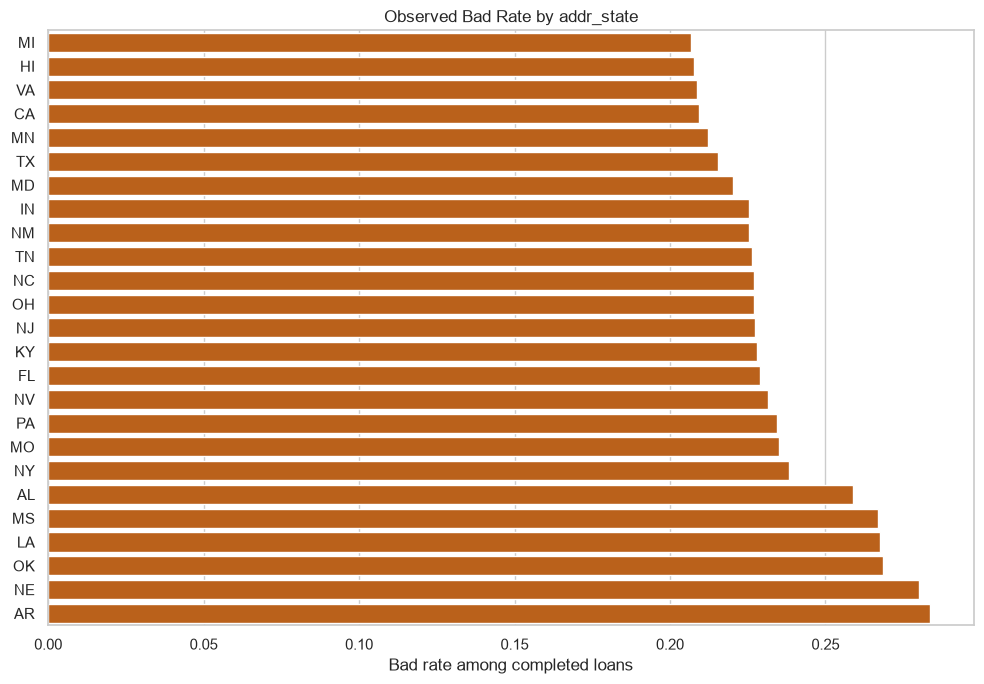

In [100]:
for col in ["grade", "sub_grade", "term", "purpose", "home_ownership", "verification_status", "application_type", "addr_state"]:
    if col not in completed:
        continue
    br = bad_rate_by_group(completed, col, min_n=CONFIG.min_group_n)
    display_and_save_table(br, f"bad_rate_by_{col}")

    if br.empty:
        continue
    plot_br = br.sort_values("bad_rate", ascending=True).tail(25)
    plt.figure(figsize=(10, max(4, 0.28 * len(plot_br))))
    sns.barplot(data=plot_br, x="bad_rate", y=col, color="#D55E00")
    plt.title(f"Observed Bad Rate by {col}")
    plt.xlabel("Bad rate among completed loans")
    plt.ylabel("")
    save_current_plot(f"observed_bad_rate_by_{col}")
    plt.show()


,fico_mean_band,n,bad_rate,bad_count
0,"(661.999, 667.0]",36210,0.2762,10001
1,"(667.0, 672.0]",17462,0.2601,4542
2,"(672.0, 677.0]",15334,0.2549,3908
3,"(677.0, 682.0]",14633,0.2472,3618
4,"(682.0, 687.0]",12819,0.2323,2978
5,"(687.0, 697.0]",23392,0.2167,5070
6,"(697.0, 707.0]",18946,0.1938,3671
7,"(707.0, 717.0]",14822,0.1765,2616
8,"(717.0, 737.0]",17555,0.1458,2559
9,"(737.0, 847.5]",18279,0.1008,1843


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_fico_mean_band.csv


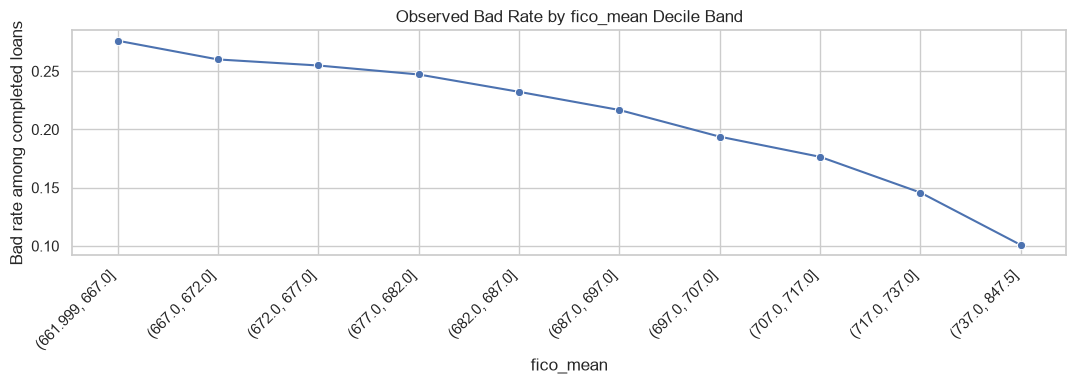

,dti_band,n,bad_rate,bad_count
9,"(31.09, 999.0]",18918,0.3179,6014
8,"(26.77, 31.09]",18929,0.2755,5215
7,"(23.53, 26.77]",18957,0.2423,4594
6,"(20.75, 23.53]",18935,0.2276,4309
5,"(18.27, 20.75]",18906,0.2117,4002
4,"(15.92, 18.27]",18929,0.1988,3763
3,"(13.53, 15.92]",18996,0.1901,3612
2,"(10.93, 13.53]",18940,0.1733,3282
1,"(7.68, 10.93]",18942,0.1628,3084
0,"(-0.001, 7.68]",18960,0.1540,2919


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_dti_band.csv


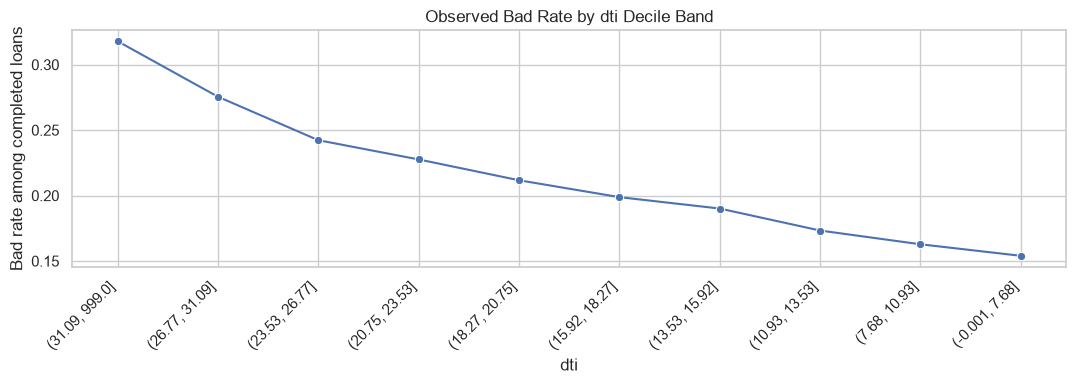

,annual_inc_band,n,bad_rate,bad_count
0,"(-0.001, 34000.0]",19348,0.2497,4831
1,"(34000.0, 42000.0]",19706,0.2452,4831
2,"(42000.0, 50000.0]",22131,0.2353,5208
3,"(50000.0, 57000.0]",15441,0.2313,3571
4,"(57000.0, 65000.0]",21661,0.2286,4951
5,"(65000.0, 74500.0]",15401,0.2145,3303
6,"(74500.0, 85000.0]",21430,0.2063,4420
7,"(85000.0, 100000.0]",18521,0.1920,3556
8,"(100000.0, 127000.0]",16989,0.1826,3102
9,"(127000.0, 9573072.0]",18824,0.1611,3033


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_annual_inc_band.csv


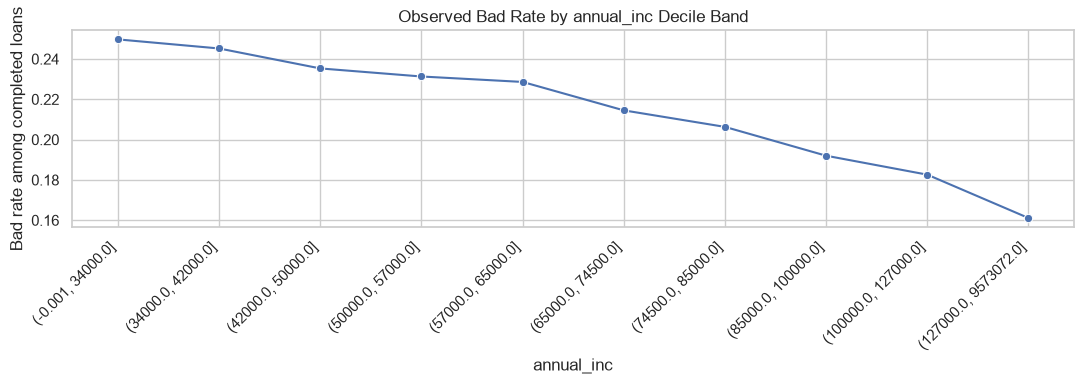

,loan_amnt_band,n,bad_rate,bad_count
9,"(28000.0, 40000.0]",16962,0.2586,4387
7,"(18175.0, 21750.0]",18944,0.2553,4837
6,"(15000.0, 18175.0]",16351,0.2527,4132
8,"(21750.0, 28000.0]",20926,0.2375,4970
4,"(10200.0, 12500.0]",19255,0.2285,4400
5,"(12500.0, 15000.0]",21080,0.2269,4783
3,"(9000.0, 10200.0]",18141,0.2006,3639
2,"(7000.0, 9000.0]",17114,0.1769,3027
1,"(5000.0, 7000.0]",16436,0.1632,2682
0,"(999.999, 5000.0]",24243,0.1629,3949


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_loan_amnt_band.csv


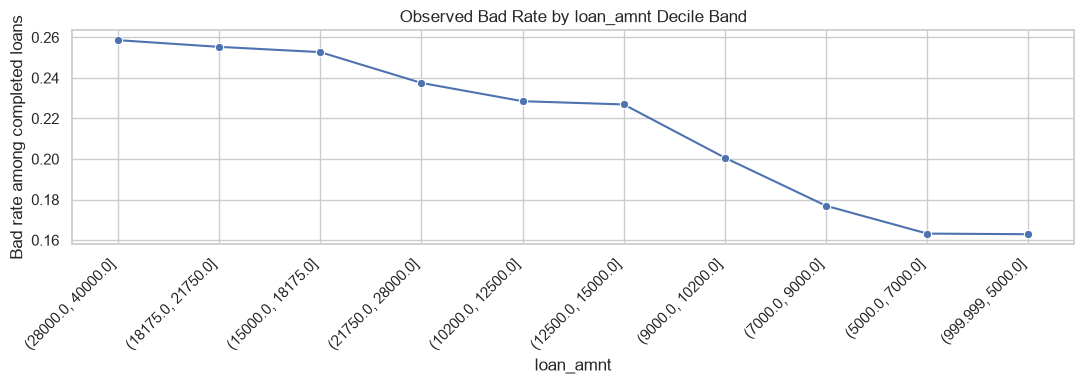

,int_rate_clean_band,n,bad_rate,bad_count
9,"(18.25, 30.99]",18207,0.4704,8564
8,"(16.55, 18.25]",16073,0.3635,5843
7,"(14.08, 16.55]",22272,0.3007,6698
6,"(13.18, 14.08]",18233,0.2578,4701
5,"(12.29, 13.18]",14056,0.2231,3136
4,"(10.99, 12.29]",22213,0.1803,4005
3,"(9.76, 10.99]",20771,0.1517,3151
2,"(8.18, 9.76]",15123,0.1247,1886
1,"(7.26, 8.18]",18901,0.0889,1680
0,"(5.308999999999999, 7.26]",23603,0.0484,1142


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_int_rate_clean_band.csv


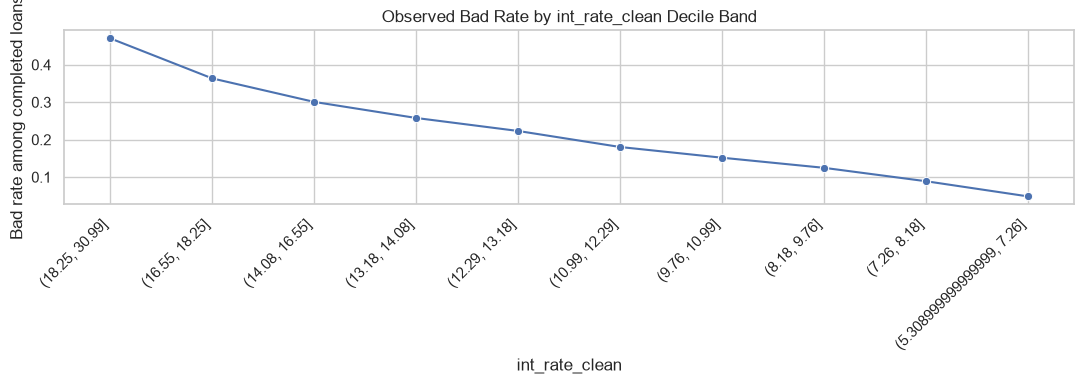

,revol_util_clean_band,n,bad_rate,bad_count
8,"(74.5, 84.9]",18952,0.2433,4611
9,"(84.9, 193.0]",18858,0.2400,4525
7,"(66.3, 74.5]",18759,0.2326,4364
6,"(58.9, 66.3]",19069,0.2319,4423
5,"(51.9, 58.9]",19016,0.2253,4285
4,"(44.9, 51.9]",18840,0.2196,4138
3,"(37.6, 44.9]",19000,0.2093,3977
2,"(29.6, 37.6]",18927,0.1981,3749
1,"(19.2, 29.6]",18906,0.1843,3485
0,"(-0.001, 19.2]",19030,0.1694,3224


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_revol_util_clean_band.csv


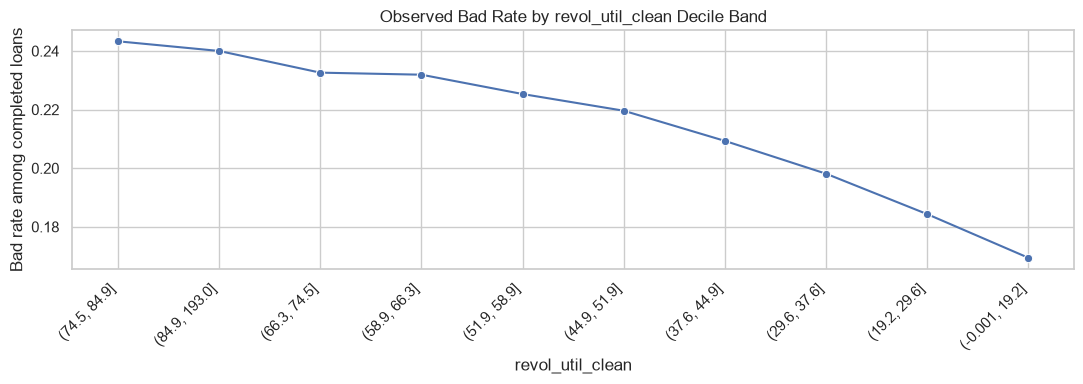

,credit_history_years_band,n,bad_rate,bad_count
0,"(3.076, 8.419]",19243,0.2441,4697
1,"(8.419, 10.585]",18802,0.2381,4477
2,"(10.585, 12.085]",18983,0.2374,4506
3,"(12.085, 13.58]",18945,0.2287,4332
4,"(13.58, 15.08]",18991,0.2136,4056
6,"(16.832, 19.165]",18888,0.2072,3913
5,"(15.08, 16.832]",19101,0.2066,3947
7,"(19.165, 21.999]",18968,0.2003,3800
8,"(21.999, 27.08]",18624,0.1894,3528
9,"(27.08, 65.914]",18907,0.1878,3550


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/bad_rate_by_credit_history_years_band.csv


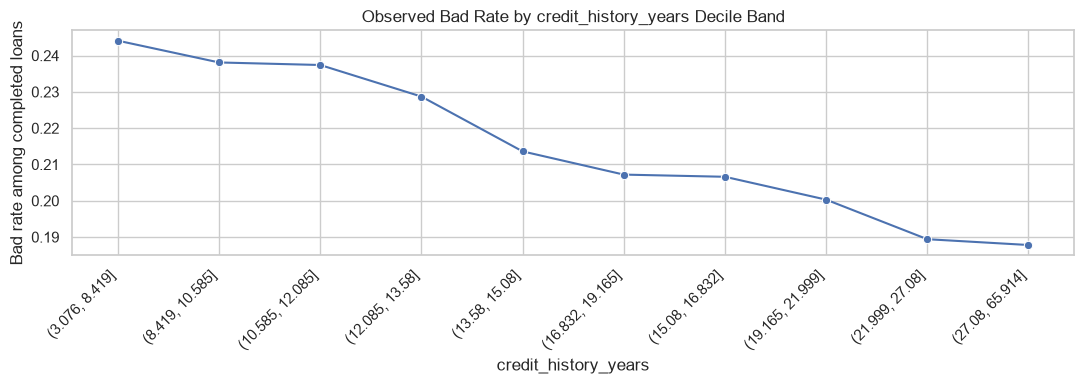

In [101]:
def add_quantile_band(df: pd.DataFrame, col: str, q: int = 10) -> pd.Series:
    s = pd.to_numeric(df[col], errors="coerce")
    try:
        return pd.qcut(s, q=q, duplicates="drop")
    except ValueError:
        return pd.Series(pd.NA, index=df.index, dtype="object")

banded = completed.copy()
for col in ["fico_mean", "dti", "annual_inc", "loan_amnt", "int_rate_clean", "revol_util_clean", "credit_history_years"]:
    if col in banded:
        band_col = f"{col}_band"
        banded[band_col] = add_quantile_band(banded, col, q=10)
        br = bad_rate_by_group(banded, band_col, min_n=CONFIG.min_group_n)
        display_and_save_table(br, f"bad_rate_by_{band_col}")
        if not br.empty:
            plot_br = br.copy()
            plot_br[band_col] = plot_br[band_col].astype(str)
            plt.figure(figsize=(11, 4))
            sns.lineplot(data=plot_br, x=band_col, y="bad_rate", marker="o", sort=False)
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Observed Bad Rate by {col} Decile Band")
            plt.xlabel(col)
            plt.ylabel("Bad rate among completed loans")
            save_current_plot(f"observed_bad_rate_by_{band_col}")
            plt.show()


,issue_year,n,bad_rate,bad_count
0,2015,163120,0.2056,33542
1,2016,11755,0.2660,3127
2,2017,8553,0.2874,2458
3,2018,6024,0.2787,1679


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_vintage_bad_rate_by_issue_year.csv


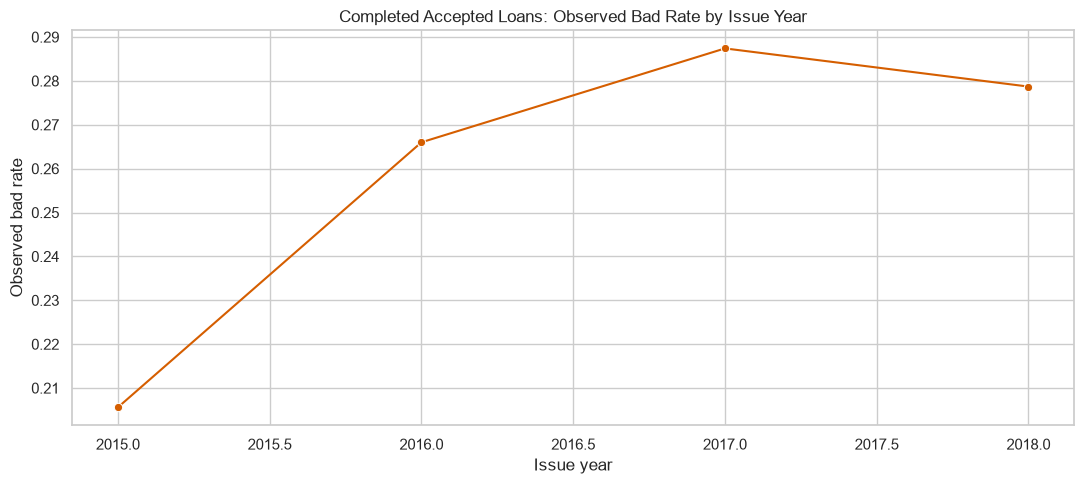

In [102]:
if {"issue_year", "target_bad"}.issubset(completed.columns):
    vintage = (
        completed.groupby("issue_year")
        .agg(n=("target_bad", "count"), bad_rate=("target_bad", "mean"), bad_count=("target_bad", "sum"))
        .reset_index()
    )
    vintage = vintage[vintage["n"] >= CONFIG.min_group_n]
    vintage["bad_rate"] = vintage["bad_rate"].round(4)
    vintage["bad_count"] = vintage["bad_count"].astype(int)
    display_and_save_table(vintage, "accepted_vintage_bad_rate_by_issue_year")

    plt.figure(figsize=(11, 5))
    sns.lineplot(data=vintage, x="issue_year", y="bad_rate", marker="o", color="#D55E00")
    plt.title("Completed Accepted Loans: Observed Bad Rate by Issue Year")
    plt.xlabel("Issue year")
    plt.ylabel("Observed bad rate")
    save_current_plot("accepted_vintage_bad_rate_by_issue_year")
    plt.show()


## 11. Relationships Among Risk, Pricing, and Loan Structure

**Description:** This section checks relationships among underwriting grade, interest rate, FICO, DTI, loan amount, term, and other structural loan characteristics.

**Importance:** A credit-risk dataset should show coherent risk-pricing behavior. For example, lower grades should generally receive higher interest rates, and riskier borrower attributes should align with higher observed risk or pricing.

**Process Made:** The notebook creates cross-variable plots and correlation-style summaries for cleaned numeric fields and key categorical risk tiers.

**Expected Results:** Economically sensible patterns linking risk grades, pricing, borrower credit quality, loan term, and loan amount. The section should also surface unexpected relationships that require review.

**Caveats:** These relationships are not causal estimates. Pricing includes LendingClub policy, investor demand, calendar time, and product strategy, so correlations should not be interpreted as independent risk effects.


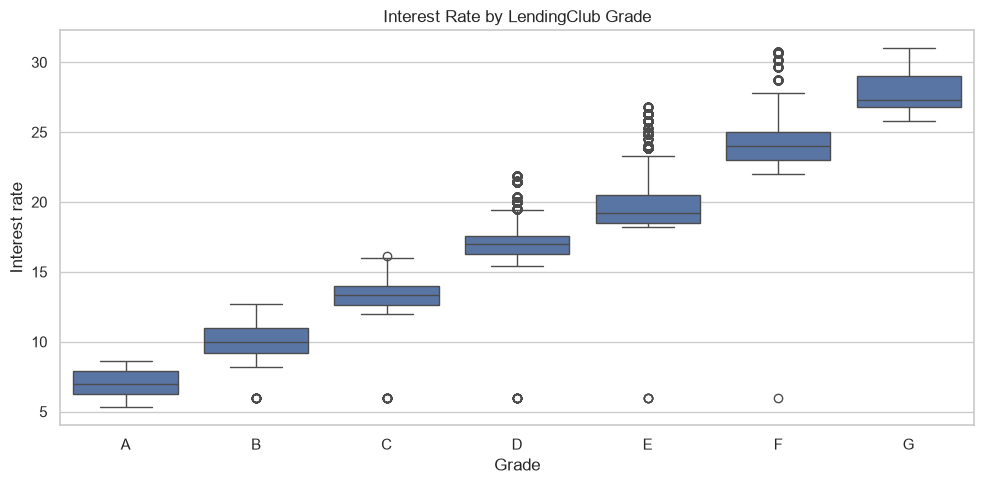

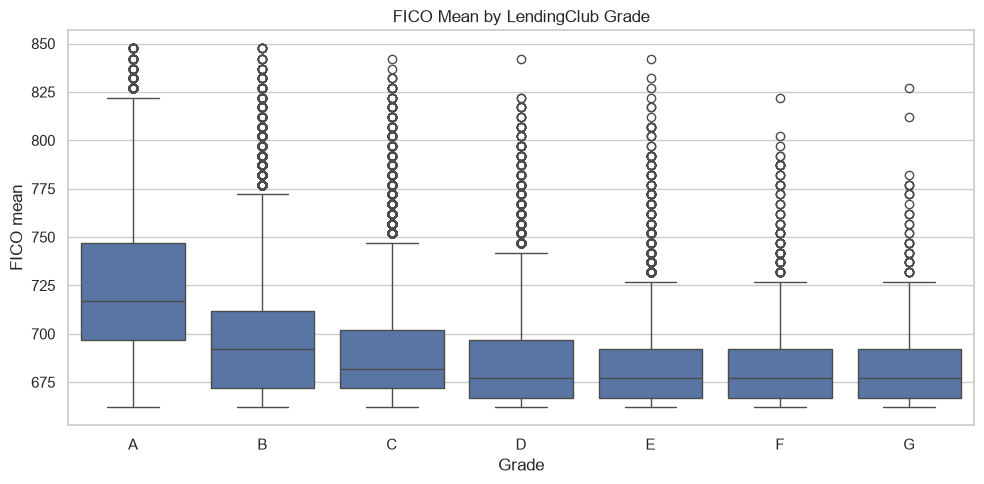

In [103]:
if {"grade", "int_rate_clean"}.issubset(accepted.columns):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=accepted, x="grade", y="int_rate_clean", order=sorted(accepted["grade"].dropna().unique()))
    plt.title("Interest Rate by LendingClub Grade")
    plt.xlabel("Grade")
    plt.ylabel("Interest rate")
    save_current_plot("accepted_interest_rate_by_grade")
    plt.show()

if {"grade", "fico_mean"}.issubset(accepted.columns):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=accepted, x="grade", y="fico_mean", order=sorted(accepted["grade"].dropna().unique()))
    plt.title("FICO Mean by LendingClub Grade")
    plt.xlabel("Grade")
    plt.ylabel("FICO mean")
    save_current_plot("accepted_fico_by_grade")
    plt.show()


,column,loan_amnt,int_rate_clean,installment,annual_inc,dti,fico_mean,emp_length_years,credit_history_years,open_acc,revol_bal,revol_util_clean,total_acc,mort_acc,bc_util,tot_cur_bal,target_bad
0,loan_amnt,1.000000,0.128428,0.952574,0.276875,0.014589,0.123056,0.080684,0.157113,0.188630,0.320204,0.111941,0.209193,0.227577,0.051472,0.319517,0.071753
1,int_rate_clean,0.128428,1.000000,0.124643,-0.079304,0.175560,-0.376168,-0.021330,-0.146651,-0.012718,-0.054341,0.187228,-0.041212,-0.082750,0.209827,-0.082685,0.303426
2,installment,0.952574,0.124643,1.000000,0.269815,0.011811,0.082294,0.067689,0.141289,0.173571,0.308815,0.123223,0.182779,0.198532,0.066684,0.293066,0.044686
3,annual_inc,0.276875,-0.079304,0.269815,1.000000,-0.142054,0.063891,0.058703,0.116809,0.114685,0.244073,0.037238,0.147995,0.189347,-0.000331,0.343857,-0.035110
4,dti,0.014589,0.175560,0.011811,-0.142054,1.000000,-0.048498,0.029082,0.032212,0.241270,0.110766,0.146652,0.186689,-0.037968,0.157003,-0.001765,0.100859
5,fico_mean,0.123056,-0.376168,0.082294,0.063891,-0.048498,1.000000,0.032348,0.108291,0.036168,0.041150,-0.431792,0.019971,0.095159,-0.458073,0.136641,-0.132704
6,emp_length_years,0.080684,-0.021330,0.067689,0.058703,0.029082,0.032348,1.000000,0.214723,0.038731,0.080172,0.024640,0.096286,0.192422,0.017968,0.098834,-0.014517
7,credit_history_years,0.157113,-0.146651,0.141289,0.116809,0.032212,0.108291,0.214723,1.000000,0.135085,0.205700,0.009902,0.267462,0.285606,-0.005009,0.177850,-0.040923
8,open_acc,0.188630,-0.012718,0.173571,0.114685,0.241270,0.036168,0.038731,0.135085,1.000000,0.220643,-0.149615,0.708671,0.123702,-0.106770,0.247123,0.035320
9,revol_bal,0.320204,-0.054341,0.308815,0.244073,0.110766,0.041150,0.080172,0.205700,0.220643,1.000000,0.234852,0.180891,0.206771,0.158798,0.453694,-0.025772


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_completed_numeric_correlation.csv


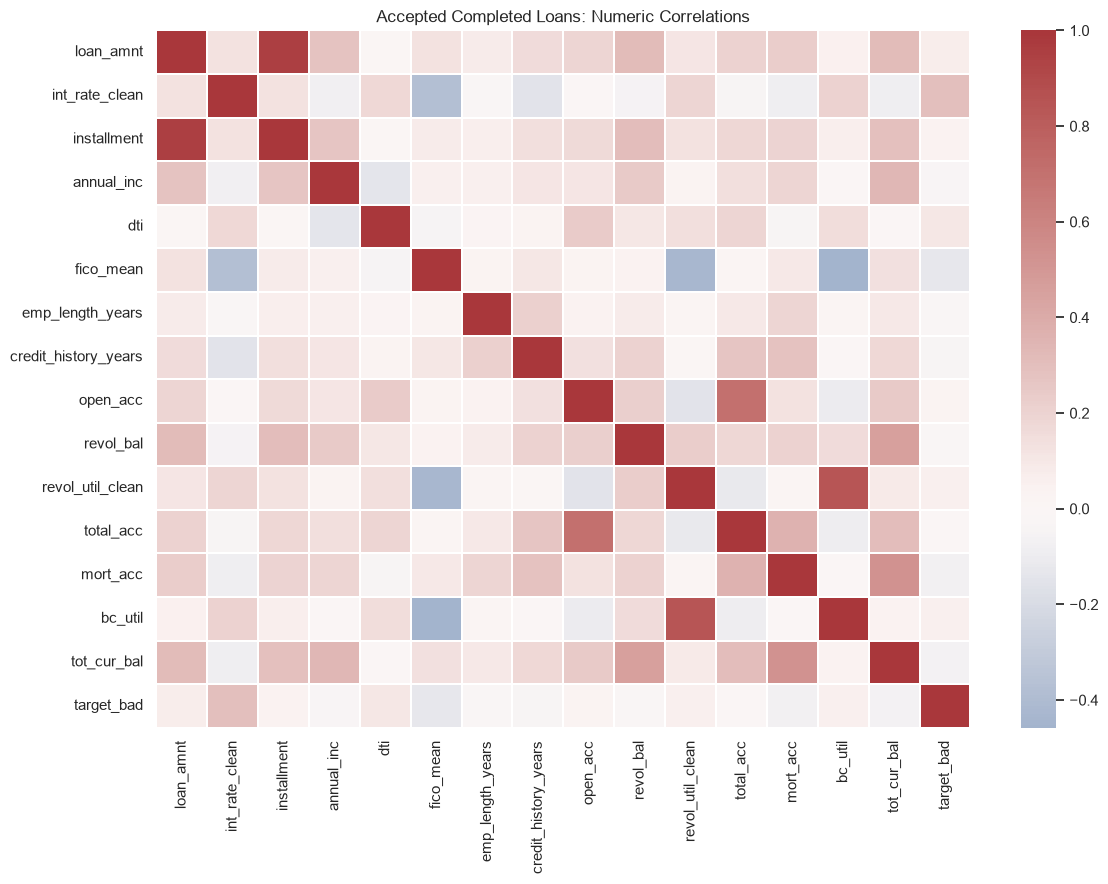

In [104]:
corr_cols = [
    "loan_amnt", "int_rate_clean", "installment", "annual_inc", "dti", "fico_mean",
    "emp_length_years", "credit_history_years", "open_acc", "revol_bal", "revol_util_clean",
    "total_acc", "mort_acc", "bc_util", "tot_cur_bal", "target_bad",
]
corr_cols = [c for c in corr_cols if c in completed]
if len(corr_cols) >= 3:
    corr = completed[corr_cols].corr(numeric_only=True)
    display_and_save_table(corr.reset_index(names="column"), "accepted_completed_numeric_correlation")

    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.2)
    plt.title("Accepted Completed Loans: Numeric Correlations")
    save_current_plot("accepted_completed_numeric_correlation_heatmap")
    plt.show()


## 12. Leakage Audit

**Description:** This section identifies accepted-loan fields that would leak future or post-origination information into an at-application repayment-risk model.

**Importance:** Leakage is one of the highest-risk failure modes in credit modeling. Payment, recovery, settlement, hardship, last-FICO, and last-credit-pull fields can make validation metrics look artificially strong because they are known only after origination.

**Process Made:** The notebook categorizes raw columns by leakage risk, flags post-origination servicing and outcome fields, and separates application-time candidates from fields requiring exclusion or business/timestamp review.

**Expected Results:** A leakage audit table that can be used as a feature-exclusion control before modeling.

**Caveats:** Some fields may be ambiguous without source-system timing metadata. Ambiguous features should be excluded from first-pass modeling or reviewed before use, especially if they could be created after underwriting.


In [105]:
CLEAR_LEAKAGE_EXCLUDE = [
    "pymnt_plan", "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries",
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low", "hardship_flag",
    "hardship_type", "hardship_reason", "hardship_status", "deferral_term", "hardship_amount",
    "hardship_start_date", "hardship_end_date", "payment_plan_start_date", "hardship_length",
    "hardship_dpd", "hardship_loan_status", "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount", "debt_settlement_flag",
    "debt_settlement_flag_date", "settlement_status", "settlement_date", "settlement_amount",
    "settlement_percentage", "settlement_term",
]

AMBIGUOUS_REVIEW_REQUIRED = [
    "funded_amnt", "funded_amnt_inv", "url", "desc", "title", "zip_code",
    "initial_list_status", "policy_code", "disbursement_method", "emp_title", "addr_state",
]

MODEL_EXCLUDE_IDENTIFIER_TARGET = ["id", "member_id", "loan_status", "target_bad", "target_definition"]

leakage_audit = []
for col in accepted_columns:
    if col in CLEAR_LEAKAGE_EXCLUDE:
        label = "exclude_clear_post_origination_leakage"
    elif col in AMBIGUOUS_REVIEW_REQUIRED:
        label = "review_timing_or_compliance_before_use"
    elif col in MODEL_EXCLUDE_IDENTIFIER_TARGET:
        label = "exclude_identifier_or_target"
    elif col in APPLICATION_TIME_CANDIDATES:
        label = "candidate_application_time_feature"
    else:
        label = "not_in_working_sample_review_before_use"
    leakage_audit.append({"column": col, "recommendation": label})

leakage_audit = pd.DataFrame(leakage_audit)
display_and_save_table(leakage_audit, "accepted_leakage_audit_all_raw_columns")
leakage_audit["recommendation"].value_counts()


,column,recommendation
0,id,exclude_identifier_or_target
1,member_id,exclude_identifier_or_target
2,loan_amnt,candidate_application_time_feature
3,funded_amnt,review_timing_or_compliance_before_use
4,funded_amnt_inv,review_timing_or_compliance_before_use
...,...,...
146,settlement_status,exclude_clear_post_origination_leakage
147,settlement_date,exclude_clear_post_origination_leakage
148,settlement_amount,exclude_clear_post_origination_leakage
149,settlement_percentage,exclude_clear_post_origination_leakage


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_leakage_audit_all_raw_columns.csv


recommendation
candidate_application_time_feature         86
exclude_clear_post_origination_leakage     38
not_in_working_sample_review_before_use    13
review_timing_or_compliance_before_use     11
exclude_identifier_or_target                3
Name: count, dtype: int64

## 13. Modeling-Readiness Recommendations

**Description:** This section converts EDA findings into a recommended supervised modeling frame.

**Importance:** EDA should end with actionable modeling controls: population definition, label definition, feature exclusions, validation design, missingness treatment, and governance risks.

**Process Made:** The notebook summarizes the recommended accepted-loan population, completed-loan `target_bad` label, unresolved-loan exclusion, chronological validation, leakage exclusions, proxy-risk field review, and calibration diagnostics.

**Expected Results:** A clear modeling-readiness checklist that can guide the next notebook or pipeline implementation.

**Caveats:** These recommendations are not a production model approval. Final modeling still needs train-only preprocessing, hyperparameter tuning, out-of-time validation, calibration testing, stability checks, fairness/proxy review, and documentation of limitations.

Recommended supervised modeling frame:

- Population: accepted/originated loans only.
- Label: completed-loan `target_bad`, where bad is charged-off/default/late and good is fully paid.
- Exclude: current/unresolved loans from binary PD training, unless using survival analysis.
- Split: chronological train/validation/test by `issue_d`, not random-only validation.
- Features: application-time variables after leakage, timing, missingness, and compliance review.
- Geography/text: treat `addr_state`, `zip_code`, `title`, `desc`, and `emp_title` as proxy-risk or privacy-risk fields requiring fairness and governance review.
- Calibration: evaluate rank ordering and probability calibration by vintage, grade, term, FICO, DTI, and loan amount.

Key limitation: because denied loans are intentionally excluded, this model estimates repayment risk **conditional on approval**. It does not estimate default risk for rejected applicants or optimize approval policy across all applicants.


In [106]:
SAFE_STARTER_FEATURES = [
    "loan_amnt", "term_months", "int_rate_clean", "installment", "grade", "sub_grade",
    "emp_length_years", "home_ownership", "annual_inc", "verification_status", "purpose",
    "dti", "delinq_2yrs", "fico_mean", "inq_last_6mths", "mths_since_last_delinq",
    "mths_since_last_record", "open_acc", "pub_rec", "revol_bal", "revol_util_clean",
    "total_acc", "credit_history_years", "collections_12_mths_ex_med", "acc_now_delinq",
    "tot_coll_amt", "tot_cur_bal", "acc_open_past_24mths", "avg_cur_bal", "bc_open_to_buy",
    "bc_util", "mort_acc", "pub_rec_bankruptcies", "tax_liens", "total_bal_ex_mort",
    "total_bc_limit", "total_il_high_credit_limit", "application_type",
]
SAFE_STARTER_FEATURES = [c for c in SAFE_STARTER_FEATURES if c in accepted.columns]

modeling_readiness = pd.DataFrame([
    {"item": "source_population", "recommendation": "Accepted/originated LendingClub loans only"},
    {"item": "target", "recommendation": "target_bad on completed loans; exclude unresolved current loans for binary PD"},
    {"item": "validation", "recommendation": "Use issue-date chronological split; report vintage stability"},
    {"item": "leakage", "recommendation": "Drop all payment, recovery, hardship, settlement, last-FICO, and last-credit-pull fields"},
    {"item": "fair_lending", "recommendation": "Review geography, text, employment title, and any proxy-risk variables before production framing"},
    {"item": "starter_feature_count", "recommendation": str(len(SAFE_STARTER_FEATURES))},
])
display_and_save_table(modeling_readiness, "accepted_modeling_readiness_recommendations")

pd.Series(SAFE_STARTER_FEATURES, name="starter_feature").to_csv(TABLE_DIR / "accepted_safe_starter_features.csv", index=False)
print("Starter feature list saved:", TABLE_DIR / "accepted_safe_starter_features.csv")
print(SAFE_STARTER_FEATURES)


,item,recommendation
0,source_population,Accepted/originated LendingClub loans only
1,target,target_bad on completed loans; exclude unresol...
2,validation,Use issue-date chronological split; report vin...
3,leakage,"Drop all payment, recovery, hardship, settleme..."
4,fair_lending,"Review geography, text, employment title, and ..."
5,starter_feature_count,38


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_modeling_readiness_recommendations.csv
Starter feature list saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_safe_starter_features.csv
['loan_amnt', 'term_months', 'int_rate_clean', 'installment', 'grade', 'sub_grade', 'emp_length_years', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_mean', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util_clean', 'total_acc', 'credit_history_years', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_

In [107]:
if "issue_d_dt" in completed and len(completed):
    split_frame = completed[["issue_d_dt", "target_bad"]].dropna().sort_values("issue_d_dt")
    q_train, q_valid = split_frame["issue_d_dt"].quantile([0.70, 0.85])
    split_plan = pd.DataFrame([
        {"split": "train", "date_rule": f"issue_d <= {q_train.date()}"},
        {"split": "validation", "date_rule": f"{q_train.date()} < issue_d <= {q_valid.date()}"},
        {"split": "test", "date_rule": f"issue_d > {q_valid.date()}"},
    ])
    display_and_save_table(split_plan, "accepted_recommended_time_split_plan")


,split,date_rule
0,train,issue_d <= 2015-11-01
1,validation,2015-11-01 < issue_d <= 2015-12-01
2,test,issue_d > 2015-12-01


Saved: /Users/lindaperez/Documents/NEU/2026SummerML/MachineLearningClass/Final_Project/Final/CreditRiskRAG/EDA/accepted_eda_outputs/tables/accepted_recommended_time_split_plan.csv


## 14. Final EDA Conclusions

**Description:** This section summarizes the main analytical and governance conclusions from the accepted-loan EDA.

**Importance:** Final EDA conclusions should connect the technical analysis to credit-risk modeling decisions: what population is modeled, how the target is defined, which fields are excluded, and how validation should be designed.

**Process Made:** The notebook consolidates evidence from schema review, sampling, cleaning, target mapping, missingness, univariate/bivariate EDA, temporal analysis, bad-rate analysis, and leakage audit outputs saved under `accepted_eda_outputs/`.

**Expected Results:** A concise set of stable conclusions that remain valid even if the EDA sample size is changed, supported by exported tables and plots.

**Caveats:** Conclusions apply to accepted/originated LendingClub loans only. They do not support claims about rejected applicants, approval policy optimization, or production use without additional modeling, validation, fair-lending, and governance work.

After running this notebook, use the generated tables and plots under `accepted_eda_outputs/` to support the final modeling plan. The most important governance conclusions should remain stable even if the sample size is changed:

1. The accepted-loan file contains valid repayment outcomes; denied loans are not needed for accepted-population repayment-risk modeling.
2. `loan_status` must be converted into a carefully documented target, and unresolved loans should not be treated as good loans.
3. Time drift is expected; validation should be chronological and vintage-aware.
4. Many accepted-loan fields are post-origination leakage and must be excluded from at-origination models.
5. Geography and text fields require fair-lending/privacy review before use.
6. Any final model should document that it predicts repayment risk among borrowers who passed LendingClub's historical acceptance process.
